# Geo Sentiment Fix - IndoBERT Only

Notebook ini adalah versi fokus dari `geo_sentiment_bagian3_8_v2_refactored.ipynb`.

Fokus utama:
- Model tunggal: OPT IndoBERT.
- Imbalance handling: negative class weight boost, focal/weighted loss, early stopping in-memory, dan threshold tuning.
- Target evaluasi: Recall-NEG sebagai prioritas, Macro-F1 sebagai penjaga keseimbangan.
- Augmentasi negatif back-translation hanya pada train set dengan filter kualitas dan anti-leakage.


In [1]:
# ============================================================
# CELL 0.1 - Install Dependencies
# ============================================================
# Set True hanya saat dependency belum tersedia.
INSTALL = False

if INSTALL:
    import subprocess
    import sys

    pkgs = [
        "PySastrawi", "nltk", "scikit-learn",
        "transformers", "accelerate", "torch",
        "pandas", "numpy", "matplotlib", "seaborn",
        "wordcloud", "tqdm", "sentencepiece", "sacremoses",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U"] + pkgs)
    print("Dependency selesai di-install. Jika baru install sentencepiece/sacremoses, restart kernel dulu.")
else:
    print("Install dilewati. Set INSTALL=True jika dependency belum tersedia.")


Install dilewati. Set INSTALL=True jika dependency belum tersedia.


In [2]:
# ============================================================
# CELL 0.2 - Import & Konfigurasi
# ============================================================
import os
import re
import json
import time
import random
import warnings
from pathlib import Path
from collections import Counter
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
tqdm.pandas()

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
for res in ("punkt", "stopwords", "punkt_tab"):
    try:
        nltk.download(res, quiet=True)
    except Exception:
        pass
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords as nltk_sw

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    STEMMER = StemmerFactory().create_stemmer()
    SASTRAWI_OK = True
except ImportError:
    STEMMER = None
    SASTRAWI_OK = False

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve, auc
)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset as TorchDataset
    from transformers import (
        AutoTokenizer, AutoModelForSequenceClassification,
        TrainingArguments, Trainer, TrainerCallback, pipeline
    )
    TORCH_OK = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    TORCH_OK = False
    DEVICE = "cpu"

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
if TORCH_OK:
    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
SPLIT_DIR = DATA_DIR / "split"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = BASE_DIR / "output" / "geo_sentiment_fix"
MODEL_DIR = BASE_DIR / "model" / "geo_sentiment_fix"
for d in [PROCESSED_DIR, OUTPUT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

INDOBERT_MODEL = "mdhugol/indonesia-bert-sentiment-classification"
LABEL_NAMES = {0: "Negatif", 1: "Positif"}
LABEL_COLORS = {0: "#E74C3C", 1: "#27AE60"}

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "figure.figsize": (10, 5)})
sns.set_theme(style="whitegrid")

print("=" * 60)
print("ENVIRONMENT CHECK - IndoBERT Only")
print("=" * 60)
print(f"PySastrawi : {'OK' if SASTRAWI_OK else 'MISSING - pip install PySastrawi'}")
print(f"PyTorch    : {'OK' if TORCH_OK else 'MISSING - pip install torch transformers'}")
print(f"Device     : {DEVICE}")
print(f"Output dir : {OUTPUT_DIR}")
print("=" * 60)


ENVIRONMENT CHECK - IndoBERT Only
PySastrawi : OK
PyTorch    : OK
Device     : cuda
Output dir : output\geo_sentiment_fix


## 0.3. Helper Load Cache dan Model Tersimpan

Gunakan cell ini untuk menjalankan notebook di Colab/local tanpa preprocessing, labeling, atau training ulang jika artefak hasil fix sudah tersedia.


In [ ]:
# ============================================================
# CELL 0.3 - Helper Load Cache Processed/Labeled dan Model OPT IndoBERT
# ============================================================
# Contoh Colab:
# ARTIFACT_ROOT = "/content/geo_sentiment_fix_artifacts"
# artifacts = load_fix_artifacts(ARTIFACT_ROOT, load_model=True, load_labeled=True)
#
# Setelah labeling pertama kali selesai, simpan cache agar run berikutnya cepat:
# save_processed_labeled_cache()

class LoadedIndoBERTWrapper:
    """Wrapper ringan agar model hasil load tetap kompatibel dengan predict_sentiment_indobert."""
    def __init__(self, model):
        self.model = model


def _as_path(p):
    return p if isinstance(p, Path) else Path(str(p))


def _existing_path(candidates, desc):
    for cand in candidates:
        p = _as_path(cand)
        if p.exists():
            return p
    raise FileNotFoundError(f"{desc} tidak ditemukan. Kandidat: {[str(c) for c in candidates]}")


def _artifact_roots(root=None):
    roots = []
    if root is not None:
        roots.append(_as_path(root))
    roots.extend([
        BASE_DIR,
        Path("."),
        Path("notebooks"),
        Path("/content/geo_sentiment_fix_artifacts"),
        Path("/content/drive/MyDrive/geo_sentiment_fix_artifacts"),
    ])
    unique = []
    seen = set()
    for r in roots:
        key = str(r)
        if key not in seen:
            unique.append(r)
            seen.add(key)
    return unique


def set_fix_artifact_dirs(root=None):
    """Set DATA_DIR/PROCESSED_DIR/OUTPUT_DIR/MODEL_DIR ke folder artefak fix."""
    root_path = _as_path(root) if root is not None else BASE_DIR
    dirs = {
        "BASE_DIR": root_path,
        "DATA_DIR": root_path / "data",
        "RAW_DIR": root_path / "data" / "raw",
        "SPLIT_DIR": root_path / "data" / "split",
        "PROCESSED_DIR": root_path / "data" / "processed",
        "OUTPUT_DIR": root_path / "output" / "geo_sentiment_fix",
        "MODEL_DIR": root_path / "model" / "geo_sentiment_fix",
    }
    dirs["PROCESSED_DIR"].mkdir(parents=True, exist_ok=True)
    dirs["OUTPUT_DIR"].mkdir(parents=True, exist_ok=True)
    dirs["MODEL_DIR"].mkdir(parents=True, exist_ok=True)
    globals().update(dirs)
    print(f"[ARTIFACT] Root aktif: {root_path}")
    return dirs


def _processed_candidates(filename, root=None):
    candidates = []
    for r in _artifact_roots(root):
        candidates.extend([
            r / "data" / "processed" / filename,
            r / "notebooks" / "data" / "processed" / filename,
            r / filename,
        ])
    candidates.extend([
        PROCESSED_DIR / filename,
        Path("data/processed") / filename,
        Path("notebooks/data/processed") / filename,
        Path("/content") / filename,
    ])
    return candidates


def load_processed_text_cache(root=None, filename="all_platforms_preprocessed.csv", set_global=True):
    """Load hasil text processing agar tidak perlu menjalankan CELL 3.1-3.3 ulang."""
    path = _existing_path(_processed_candidates(filename, root), "File processed text")
    loaded = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
    required_any = {"text_bert", "text_ml", "review_text"}
    if not required_any.intersection(loaded.columns):
        raise ValueError(f"{path} tidak terlihat seperti file processed text. Kolom: {list(loaded.columns)[:20]}")
    if set_global:
        globals()["df"] = loaded.copy()
        globals()["df_processed_cache"] = loaded.copy()
    print(f"[CACHE] Processed text loaded: {path} shape={loaded.shape}")
    return loaded


def _split_file_candidates(split_name, root=None):
    filenames = [
        f"{split_name}_labeled_binary.csv",
        f"{split_name}_processed_labeled.csv",
        f"{split_name}_fix.csv",
    ]
    out = []
    for fn in filenames:
        out.extend(_processed_candidates(fn, root))
        for r in _artifact_roots(root):
            out.extend([
                r / "output" / "geo_sentiment_fix" / fn,
                r / "notebooks" / "output" / "geo_sentiment_fix" / fn,
            ])
    return out


def load_processed_labeled_cache(root=None, set_global=True):
    """
    Load cache hasil text processing + labeling.
    Prioritas: train/val/test split jika tersedia, lalu fallback ke all_platforms_labeled_binary.csv.
    """
    split_paths = {}
    for split_name in ["train", "val", "test"]:
        try:
            split_paths[split_name] = _existing_path(_split_file_candidates(split_name, root), f"Split {split_name}")
        except FileNotFoundError:
            split_paths = {}
            break

    loaded = {}
    if split_paths:
        for split_name, path in split_paths.items():
            loaded[split_name] = pd.read_csv(path, encoding="utf-8-sig", low_memory=False)
            if "label" not in loaded[split_name].columns:
                raise ValueError(f"{path} tidak punya kolom label.")
        if set_global:
            globals()["df_train"] = loaded["train"].copy()
            globals()["df_val"] = loaded["val"].copy()
            globals()["df_test"] = loaded["test"].copy()
            globals()["df_train_final"] = globals()["df_train"]
            globals()["df_val_final"] = globals()["df_val"]
            globals()["df_test_final"] = globals()["df_test"]
            globals()["y_train"] = globals()["df_train"]["label"].to_numpy()
            globals()["y_val"] = globals()["df_val"]["label"].to_numpy()
            globals()["y_test"] = globals()["df_test"]["label"].to_numpy()
            globals()["df"] = pd.concat(
                [globals()["df_train"], globals()["df_val"], globals()["df_test"]],
                ignore_index=True,
            )
        print("[CACHE] Labeled split loaded:")
        for split_name, path in split_paths.items():
            print(f"  - {split_name}: {path} shape={loaded[split_name].shape}")
        return loaded

    labeled_path = _existing_path(
        _processed_candidates("all_platforms_labeled_binary.csv", root)
        + _processed_candidates("all_platforms_processed_labeled.csv", root),
        "File labeled binary",
    )
    labeled = pd.read_csv(labeled_path, encoding="utf-8-sig", low_memory=False)
    if "label" not in labeled.columns:
        raise ValueError(f"{labeled_path} tidak punya kolom label.")
    if set_global:
        globals()["df"] = labeled.copy()
        globals()["df_labeled_cache"] = labeled.copy()
    print(f"[CACHE] Labeled data loaded: {labeled_path} shape={labeled.shape}")
    return {"all": labeled}


def save_processed_labeled_cache(root=None, include_splits=True):
    """Simpan df berlabel dan split train/val/test agar run berikutnya bisa langsung load."""
    dirs = set_fix_artifact_dirs(root) if root is not None else {
        "PROCESSED_DIR": PROCESSED_DIR,
        "OUTPUT_DIR": OUTPUT_DIR,
    }
    processed_dir = dirs["PROCESSED_DIR"]
    saved = {}

    if "df" in globals() and isinstance(df, pd.DataFrame) and "label" in df.columns:
        path = processed_dir / "all_platforms_labeled_binary.csv"
        df.to_csv(path, index=False, encoding="utf-8-sig")
        saved["all_labeled"] = path

    if include_splits:
        for name in ["train", "val", "test"]:
            var_name = f"df_{name}"
            if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
                split_df = globals()[var_name]
                if "label" in split_df.columns:
                    path = processed_dir / f"{name}_labeled_binary.csv"
                    split_df.to_csv(path, index=False, encoding="utf-8-sig")
                    saved[name] = path

    if not saved:
        raise RuntimeError("Tidak ada df berlabel/split berlabel di memori. Jalankan labeling/split dulu sekali.")

    print("[CACHE] File labeled cache disimpan:")
    for key, path in saved.items():
        print(f"  - {key}: {path}")
    return saved


def _model_candidates(model_subdir="indobert_opt_recall_neg", root=None):
    candidates = []
    for r in _artifact_roots(root):
        candidates.extend([
            r / "model" / "geo_sentiment_fix" / model_subdir,
            r / "notebooks" / "model" / "geo_sentiment_fix" / model_subdir,
            r / model_subdir,
        ])
    candidates.extend([
        MODEL_DIR / model_subdir,
        Path("model/geo_sentiment_fix") / model_subdir,
        Path("notebooks/model/geo_sentiment_fix") / model_subdir,
        Path("/content") / model_subdir,
    ])
    return candidates


def load_opt_indobert_model(root=None, model_subdir="indobert_opt_recall_neg", set_global=True):
    """Load model OPT IndoBERT tersimpan agar tidak perlu fine-tuning ulang."""
    if not TORCH_OK:
        raise RuntimeError("PyTorch/Transformers belum tersedia. Install requirements lalu restart kernel.")

    model_path = _existing_path(_model_candidates(model_subdir, root), "Folder model OPT IndoBERT")
    threshold_path = model_path / "threshold_config.json"
    threshold_cfg = {}
    if threshold_path.exists():
        threshold_cfg = json.loads(threshold_path.read_text(encoding="utf-8"))
    threshold = float(threshold_cfg.get("threshold", threshold_cfg.get("best_threshold", 0.5)))

    tokenizer_loaded = AutoTokenizer.from_pretrained(model_path)
    model_loaded = AutoModelForSequenceClassification.from_pretrained(model_path)
    model_loaded.to(DEVICE)
    model_loaded.eval()

    model_name = "OPT IndoBERT + weighted loss + early_stop + threshold"
    result_entry = {
        "model": LoadedIndoBERTWrapper(model_loaded),
        "tokenizer": tokenizer_loaded,
        "threshold": threshold,
        "threshold_config": threshold_cfg,
    }

    if set_global:
        globals()["tokenizer_opt"] = tokenizer_loaded
        globals()["model_opt"] = model_loaded
        globals()["best_threshold"] = threshold
        globals()["BEST_THRESHOLD"] = threshold
        globals()["ALL_RESULTS"] = {model_name: result_entry}
        globals()["df_results"] = pd.DataFrame([{
            "Model": model_name,
            "Threshold": threshold,
            "Source": "loaded_saved_model",
        }])
        globals()["OPT_BERT_MAX_LEN"] = globals().get("OPT_BERT_MAX_LEN", 160)

    print(f"[MODEL] OPT IndoBERT loaded: {model_path}")
    print(f"[MODEL] Threshold POS aktif: {threshold:.4f} | Device: {DEVICE}")
    return result_entry


def load_spatial_cache(root=None, set_global=True):
    """Load cache output spatial jika sudah pernah dibuat."""
    spatial_review_path = _existing_path(
        [
            *[r / "output" / "geo_sentiment_fix" / "spatial_review_predictions.csv" for r in _artifact_roots(root)],
            *[r / "notebooks" / "output" / "geo_sentiment_fix" / "spatial_review_predictions.csv" for r in _artifact_roots(root)],
            OUTPUT_DIR / "spatial_review_predictions.csv",
        ],
        "spatial_review_predictions.csv",
    )
    spatial_summary_path = _existing_path(
        [
            *[r / "output" / "geo_sentiment_fix" / "spatial_location_summary.csv" for r in _artifact_roots(root)],
            *[r / "notebooks" / "output" / "geo_sentiment_fix" / "spatial_location_summary.csv" for r in _artifact_roots(root)],
            OUTPUT_DIR / "spatial_location_summary.csv",
        ],
        "spatial_location_summary.csv",
    )
    spatial_reviews = pd.read_csv(spatial_review_path, encoding="utf-8-sig", low_memory=False)
    spatial_summary = pd.read_csv(spatial_summary_path, encoding="utf-8-sig", low_memory=False)
    if set_global:
        globals()["df_spatial"] = spatial_reviews
        globals()["df_location_summary"] = spatial_summary
    print(f"[SPATIAL] Cache review loaded: {spatial_review_path} shape={spatial_reviews.shape}")
    print(f"[SPATIAL] Cache summary loaded: {spatial_summary_path} shape={spatial_summary.shape}")
    return {"df_spatial": spatial_reviews, "df_location_summary": spatial_summary}


def load_fix_artifacts(root=None, load_model=True, load_labeled=True, load_processed=True, load_spatial=False):
    """
    Jalur cepat Colab/local.
    - load_labeled=True: coba load train/val/test labeled atau all labeled.
    - load_processed=True: fallback load all_platforms_preprocessed.csv.
    - load_model=True: load model OPT IndoBERT tersimpan + threshold.
    """
    artifacts = {}
    if root is not None:
        set_fix_artifact_dirs(root)

    if load_labeled:
        try:
            artifacts["labeled"] = load_processed_labeled_cache(root=root, set_global=True)
        except FileNotFoundError as err:
            print(f"[CACHE][INFO] Cache labeled belum ada: {err}")
            if load_processed:
                artifacts["processed"] = load_processed_text_cache(root=root, set_global=True)
    elif load_processed:
        artifacts["processed"] = load_processed_text_cache(root=root, set_global=True)

    if load_model:
        artifacts["model"] = load_opt_indobert_model(root=root, set_global=True)

    if load_spatial:
        try:
            artifacts["spatial"] = load_spatial_cache(root=root, set_global=True)
        except FileNotFoundError as err:
            print(f"[SPATIAL][INFO] Cache spatial belum ada: {err}")

    return artifacts


## 1. Load Data dan Preprocessing


In [3]:
# ============================================================
# CELL 3.1 — LOAD DATA & KAMUS NORMALISASI
# ============================================================

# ─────────────────────────────────────────────────────────────
# Load data — coba beberapa path
# ─────────────────────────────────────────────────────────────
def load_raw_data() -> pd.DataFrame:
    """Load gmaps_raw.csv dari beberapa lokasi yang mungkin."""
    candidates = [
        RAW_DIR / 'all_platforms_raw.csv',
        BASE_DIR / 'all_platforms_raw.csv',
        SPLIT_DIR / 'train_raw.csv',
        Path('/content/all_platforms_raw.csv'),          # Google Colab
        Path('/content/drive/MyDrive/all_platforms_raw.csv'),  # Colab Drive
    ]
    for p in candidates:
        if p.exists():
            df = pd.read_csv(p, encoding='utf-8-sig', low_memory=False)
            print(f'✅ Data loaded dari: {p}  shape={df.shape}')
            return df
    raise FileNotFoundError(
        'all_platforms_raw.csv tidak ditemukan.\n'
        'Upload ke: data/raw/all_platforms_raw.csv  atau  /content/all_platforms_raw.csv (Colab)'
    )

df_source = load_raw_data()

# ─────────────────────────────────────────────────────────────
# Kamus normalisasi slang & typo Indonesia
# [KONFIGURASI] Tambahkan entri baru di sini
# ─────────────────────────────────────────────────────────────
SLANG_DICT: Dict[str, str] = {
    # Negasi & kata kunci sentimen — JANGAN hapus
    'gak':'tidak','ngga':'tidak','nggak':'tidak','ga':'tidak',
    'tdk':'tidak','tak':'tidak','enggak':'tidak','gk':'tidak',
    'krg':'kurang','kurang2':'kurang',
    'tp':'tapi','tpi':'tapi',
    # Intensifier
    'bgt':'banget','bgtt':'banget','bngt':'banget',
    'sgt':'sangat','sngt':'sangat',
    'bener':'benar','bner':'benar',
    # Kata umum
    'udah':'sudah','udh':'sudah','sdh':'sudah',
    'blm':'belum','blum':'belum',
    'emg':'memang','emang':'memang','mmg':'memang',
    'krn':'karena','karna':'karena',
    'utk':'untuk','buat':'untuk',
    'dgn':'dengan','dng':'dengan','dg':'dengan',
    'dr':'dari','dri':'dari',
    'yg':'yang','yng':'yang',
    'jg':'juga','jga':'juga',
    'sy':'saya','aku':'saya',
    'klo':'kalau','klo':'kalau','kl':'kalau','kalo':'kalau',
    'lg':'lagi','lgi':'lagi',
    'msh':'masih','masi':'masih',
    'sdg':'sedang',
    # Kuliner
    'enak':'lezat','enakk':'lezat','enakkkk':'lezat',
    'mantap':'bagus','mantep':'bagus','mantul':'bagus',
    'gurih':'gurih','nyum':'nikmat','yummy':'nikmat',
    'hambar':'hambar','tawar':'hambar',
    'mie':'mie','mi':'mie','mee':'mie',
    'ayam':'ayam','bkso':'bakso','baso':'bakso',
    'porsi':'porsi','prsi':'porsi',
    'murah':'murah','mrh':'murah',
    'mahal':'mahal',
    'pedes':'pedas','pedess':'pedas',
    # Rating-related
    'bagus':'bagus','bgs':'bagus','bgus':'bagus',
    'jelek':'buruk','jlek':'buruk',
    'kecewa':'kecewa','kcewa':'kecewa',
    'puas':'puas','memuaskan':'memuaskan',
    'oke':'baik','ok':'baik',
    'rekomen':'rekomendasi','recommended':'rekomendasi',
    'worth':'sepadan','worthit':'sepadan',
    # Pelayanan
    'rmd':'ramah','rmah':'ramah',
    'lama':'lama','lamaa':'lama','lamaaa':'lama',
    'cepet':'cepat','cpet':'cepat',
    'lambat':'lambat','lmbt':'lambat',
    'bersih':'bersih','kotor':'kotor',
    'nyaman':'nyaman','nyman':'nyaman',
    # Operator
    'drever':'driver','drver':'driver',
    'ojol':'ojek online',
}

# ─────────────────────────────────────────────────────────────
# Stopwords bahasa Indonesia — PERTAHANKAN negasi & sentiment shift
# ─────────────────────────────────────────────────────────────
try:
    ID_STOPWORDS = set(nltk_sw.words('indonesian'))
except:
    ID_STOPWORDS = set()

# Kata yang HARUS dipertahankan (jangan masuk stopwords)
KEEP_WORDS: set = {
    'tidak','kurang','bukan','jangan','belum','tanpa',
    'tapi','tetapi','namun','meski','walaupun','walau',
    'sangat','banget','sekali','amat','terlalu',
    'enak','lezat','nikmat','gurih',            # aspek rasa
    'hambar','tawar','basi','buruk','jelek',     # rasa negatif
    'kecewa','puas','bagus','baik',
}
ID_STOPWORDS -= KEEP_WORDS

# Tambahkan stopwords kontekstual yang tidak relevan
ID_STOPWORDS.update([
    'mie','ayam','purwokerto','warung','tempat','sini','sana',
    'aja','nih','sih','deh','loh','dong','kok','ya','yah',
    'wkwk','haha','hehe','hihi','wkwkwk',
    'kita','kami','mereka','dia','saya',
])

print(f'📖 Kamus slang   : {len(SLANG_DICT)} entri')
print(f'🛑 Stopwords     : {len(ID_STOPWORDS)} kata (negasi dipertahankan)')
print(f'✅ Keep words    : {sorted(KEEP_WORDS)[:10]}...')


✅ Data loaded dari: data\raw\all_platforms_raw.csv  shape=(6931, 37)
📖 Kamus slang   : 105 entri
🛑 Stopwords     : 756 kata (negasi dipertahankan)
✅ Keep words    : ['amat', 'bagus', 'baik', 'banget', 'basi', 'belum', 'bukan', 'buruk', 'enak', 'gurih']...


In [4]:
# ============================================================
# CELL 3.2 — PIPELINE PREPROCESSING (Enhanced)
# ============================================================
import re

_RE_HTML    = re.compile(r'<[^>]+>')
_RE_URL     = re.compile(r'https?://\S+|www\.\S+')
_RE_MENTION = re.compile(r'@\w+')
_RE_HASHTAG = re.compile(r'#\w+')
_RE_EMOJI   = re.compile(
    '[' + '\U0001F600-\U0001F64F' + '\U0001F300-\U0001F5FF'
    + '\U0001F680-\U0001F6FF' + '\U00002702-\U000027B0' + ']+',
    flags=re.UNICODE
)
_RE_SYMBOL  = re.compile(r"[^\w\s!?]")
_RE_SPACES  = re.compile(r'\s+')
_RE_REPEAT  = re.compile(r'([^!?])\1{3,}')
_RE_QUESTION = re.compile(r'(apa|apakah|bagaimana|gimana|kenapa|mengapa|kapan|dimana|di mana|siapa|berapa)[\s\w]*\?', re.IGNORECASE)

# Kata sambung & partikel yang dihapus (tidak bermakna sentimen)
CONJUNCTION_STOPWORDS = {
    'dan','atau','tapi','tetapi','namun','melainkan','sedangkan',
    'padahal','walaupun','meskipun','karena','sebab','sehingga',
    'supaya','agar','bahwa','dengan','untuk','dari','ke','di',
    'yang','ini','itu','juga','pun','lah','kah','nya',
    'lagi','sudah','telah','akan','bisa','bisa','dapat',
    'ada','tidak','tak','jangan','bukan','belum',
}

# Stopwords kontekstual tidak relevan
CUSTOM_STOPWORDS = {
    'mie','ayam','purwokerto','warung','tempat','sini','sana',
    'aja','nih','sih','deh','loh','dong','kok','ya','yah',
    'wkwk','haha','hehe','hihi','wkwkwk',
    'kita','kami','mereka','dia','saya','aku',
    'gmaps','google','maps','review','ulasan',
}

try:
    ID_STOPWORDS = set(nltk_sw.words('indonesian'))
except:
    ID_STOPWORDS = set()

# Kata yang WAJIB dipertahankan (sentiment-bearing)
KEEP_WORDS = {
    'tidak','kurang','bukan','jangan','belum','tanpa',
    'tapi','tetapi','namun','meski','walaupun','walau',
    'sangat','banget','sekali','amat','terlalu',
    'enak','lezat','nikmat','gurih','hambar','tawar','basi',
    'buruk','jelek','kecewa','puas','bagus','baik',
    'mahal','murah','lama','cepat','lambat','ramah',
}
ID_STOPWORDS = (ID_STOPWORDS | CONJUNCTION_STOPWORDS | CUSTOM_STOPWORDS) - KEEP_WORDS

def is_question(text: str) -> bool:
    """Deteksi apakah teks adalah kalimat tanya."""
    t = text.strip().lower()
    if t.endswith('?'): return True
    if _RE_QUESTION.search(t): return True
    return False

def step1_clean(text: str) -> str:
    if not isinstance(text, str): return ''
    t = text.lower()
    t = _RE_HTML.sub(' ', t)
    t = _RE_URL.sub(' ', t)
    t = _RE_MENTION.sub(' ', t)
    t = _RE_HASHTAG.sub(' ', t)
    t = _RE_EMOJI.sub(' ', t)
    t = _RE_SYMBOL.sub(' ', t)
    t = _RE_REPEAT.sub(r'\1\1', t)
    t = re.sub(r'!{4,}', '!!!', t)
    t = re.sub(r'\?{2,}', '?', t)
    t = _RE_SPACES.sub(' ', t).strip()
    return t

def step2_normalize(text: str, slang_dict: dict = SLANG_DICT) -> str:
    if not text: return ''
    return ' '.join(slang_dict.get(tok, tok) for tok in text.split())

def step3_tokenize(text: str) -> List[str]:
    try:
        return word_tokenize(text, language='indonesian')
    except Exception:
        return text.split()

def step4_remove_stopwords(tokens: List[str], sw: set = ID_STOPWORDS, min_len: int = 2) -> List[str]:
    return [t for t in tokens if t not in sw and len(t) >= min_len and not t.isdigit()]

def step5_stem(tokens: List[str]) -> List[str]:
    if STEMMER is None: return tokens
    return [STEMMER.stem(t) for t in tokens]

def preprocess_full(text: str, apply_stem: bool = True) -> Tuple[str, str]:
    """Pipeline lengkap: clean → normalize → tokenize → stopword → stem.
    Returns (text_for_ml, text_for_bert)
    """
    cleaned    = step1_clean(text)
    normalized = step2_normalize(cleaned)
    tokens     = step3_tokenize(normalized)
    no_sw      = step4_remove_stopwords(tokens)
    stemmed    = step5_stem(no_sw) if apply_stem else no_sw
    return ' '.join(stemmed), normalized

# Demo
print('🔍 DEMO PREPROCESSING PIPELINE')
print('='*70)
DEMO = [
    'Mie ayamnya enak bgt!! Kuahnya gurih dan dagingnya lembut',
    'Tdk enak sama sekali, kuahnya hambar bgt. Ngga recommended!!!',
    'Apakah tempat ini buka hari minggu?',
    'rasa biasa aja tp harga mahal, kurang sepadan dgn kualitasnya',
    'Pelayanannya lama bgt, udah nunggu 30 menit masih blm dateng',
]
for t in DEMO:
    ml, bert = preprocess_full(t)
    q = ' [TANYA]' if is_question(t) else ''
    print(f'IN  : {t[:60]}{q}')
    print(f'ML  : {ml[:60]}')
    print('-'*70)


🔍 DEMO PREPROCESSING PIPELINE
IN  : Mie ayamnya enak bgt!! Kuahnya gurih dan dagingnya lembut
ML  : ayam lezat bgt kuah gurih daging lembut
----------------------------------------------------------------------
IN  : Tdk enak sama sekali, kuahnya hambar bgt. Ngga recommended!!
ML  : tidak lezat sekali kuah hambar banget tidak recommended
----------------------------------------------------------------------
IN  : Apakah tempat ini buka hari minggu? [TANYA]
ML  : buka minggu
----------------------------------------------------------------------
IN  : rasa biasa aja tp harga mahal, kurang sepadan dgn kualitasny
ML  : tapi harga mahal kurang padan kualitas
----------------------------------------------------------------------
IN  : Pelayanannya lama bgt, udah nunggu 30 menit masih blm dateng
ML  : layan lama banget nunggu menit belum dateng
----------------------------------------------------------------------


In [5]:
# ============================================================
# CELL 3.3 — APPLY PREPROCESSING
# ============================================================
print('🔄 Preprocessing dataset...\n')

df = df_source.copy()
n_total = len(df)
df = df.dropna(subset=['review_text'])
df = df[df['review_text'].astype(str).str.strip() != ''].copy()
n_after_drop = len(df)
print(f'① Drop NaN/empty : {n_total:,} → {n_after_drop:,} (dihapus: {n_total-n_after_drop:,})')

n_before_dup = len(df)
df = df.drop_duplicates(subset=['review_text']).copy()
print(f'② Deduplifikasi  : {n_before_dup:,} → {len(df):,} (dihapus: {n_before_dup-len(df):,} duplikat)')

# Tandai kalimat tanya sebelum preprocessing
df['is_question'] = df['review_text'].apply(lambda t: is_question(str(t)))
print(f'③ Kalimat tanya terdeteksi: {df["is_question"].sum():,}')

results = df['review_text'].progress_apply(
    lambda t: preprocess_full(str(t), apply_stem=True)
)
df['text_ml']   = results.apply(lambda x: x[0])
df['text_bert'] = results.apply(lambda x: x[1])

# Simpan kolom _year dari df_source (untuk temporal split)
if '_year' in df_source.columns:
    df = df.join(df_source[['_year']], how='left', rsuffix='_src')

df['text_ml'] = df['text_ml'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
df['text_bert'] = df['text_bert'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

mask_empty = (df['text_ml'].str.strip() == '') | (df['text_bert'].str.strip() == '')
n_empty = mask_empty.sum()
if n_empty:
    print(f'④ Drop teks kosong post-proc: {n_empty}')
    df = df[~mask_empty].copy()

# Anti-leakage: split dilakukan setelah deduplikasi teks hasil preprocessing.
# Review yang berbeda bisa berubah menjadi teks ML/BERT yang sama setelah cleaning.
for dedup_col in ['text_bert', 'text_ml']:
    n_before_text_dup = len(df)
    df = df.drop_duplicates(subset=[dedup_col]).copy()
    n_removed_text_dup = n_before_text_dup - len(df)
    if n_removed_text_dup:
        print(f'   Deduplikasi {dedup_col} post-proc: {n_before_text_dup:,} -> {len(df):,} (dihapus: {n_removed_text_dup:,})')

df['token_count'] = df['text_ml'].str.split().str.len()
print(f'\n✅ Dataset bersih: {len(df):,} baris')

proc_path = PROCESSED_DIR / 'all_platforms_preprocessed.csv'
df.to_csv(proc_path, index=False, encoding='utf-8-sig')
print(f'💾 Disimpan: {proc_path}')

print(f'\nAvg token : {df["token_count"].mean():.1f} | Median: {df["token_count"].median():.0f} | Max: {df["token_count"].max()}')



🔄 Preprocessing dataset...

① Drop NaN/empty : 6,931 → 4,516 (dihapus: 2,415)
② Deduplifikasi  : 4,516 → 4,151 (dihapus: 365 duplikat)
③ Kalimat tanya terdeteksi: 24


  0%|          | 0/4151 [00:00<?, ?it/s]

④ Drop teks kosong post-proc: 23
   Deduplikasi text_bert post-proc: 4,128 -> 3,977 (dihapus: 151)
   Deduplikasi text_ml post-proc: 3,977 -> 3,815 (dihapus: 162)

✅ Dataset bersih: 3,815 baris
💾 Disimpan: data\processed\all_platforms_preprocessed.csv

Avg token : 10.2 | Median: 6 | Max: 109


## 2. Labeling, Split, dan Augmentasi Train-Only


In [6]:
# ============================================================
# CELL 4.1 - Pelabelan IndoBERT & Split 80/10/10 Anti-Leakage
# ============================================================
if not TORCH_OK:
    raise RuntimeError("PyTorch/Transformers belum tersedia. Jalankan CELL 0.1 dengan INSTALL=True lalu restart kernel.")

print("Pelabelan otomatis menggunakan IndoBERT sentiment model...")
print(f"Model labeler: {INDOBERT_MODEL}")

# Mapping model mdhugol:
# LABEL_0 = Positive, LABEL_1 = Neutral, LABEL_2 = Negative.
# Netral di-drop agar task menjadi binary: 0=Negatif, 1=Positif.
INDOBERT_LABEL_MAP = {
    "LABEL_0": 2,
    "LABEL_1": 1,
    "LABEL_2": 0,
}

sentiment_pipe = pipeline(
    "sentiment-analysis",
    model=INDOBERT_MODEL,
    tokenizer=INDOBERT_MODEL,
    device=0 if DEVICE == "cuda" else -1,
    truncation=True,
    max_length=512,
)

def indobert_predict_batch(texts, batch_size=32):
    labels = []
    for i in tqdm(range(0, len(texts), batch_size), desc="IndoBERT labeling"):
        batch = [t if isinstance(t, str) and t.strip() else "kosong" for t in texts[i:i + batch_size]]
        results = sentiment_pipe(batch)
        labels.extend([INDOBERT_LABEL_MAP.get(r["label"], 1) for r in results])
    return labels

df = df.reset_index(drop=True).copy()
df["label_temp"] = indobert_predict_batch(df["text_bert"].tolist())

n_before = len(df)
df = df[df["label_temp"] != 1].copy()
df["label"] = df["label_temp"].replace({2: 1}).astype(int)
df = df.drop(columns=["label_temp"]).reset_index(drop=True)
print(f"Drop netral: {n_before:,} -> {len(df):,}")

print("\nDistribusi binary:")
for lbl, name in LABEL_NAMES.items():
    cnt = int((df["label"] == lbl).sum())
    pct = cnt / len(df) * 100
    print(f"  {name:8s} ({lbl}): {cnt:>5,} ({pct:5.1f}%)")

idx_train, idx_temp = train_test_split(
    df.index.to_numpy(),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df["label"].to_numpy(),
)
df_temp = df.loc[idx_temp]
idx_val, idx_test = train_test_split(
    df_temp.index.to_numpy(),
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=df_temp["label"].to_numpy(),
)

df_train_final = df.loc[idx_train].copy().reset_index(drop=True)
df_val_final = df.loc[idx_val].copy().reset_index(drop=True)
df_test_final = df.loc[idx_test].copy().reset_index(drop=True)
df_train = df_train_final
df_val = df_val_final
df_test = df_test_final

def clean_text_set(series):
    return set(series.dropna().astype(str).str.replace(r"\s+", " ", regex=True).str.strip()) - {""}

train_bert = clean_text_set(df_train["text_bert"])
val_bert = clean_text_set(df_val["text_bert"])
test_bert = clean_text_set(df_test["text_bert"])
train_ml = clean_text_set(df_train["text_ml"])
val_ml = clean_text_set(df_val["text_ml"])
test_ml = clean_text_set(df_test["text_ml"])

assert not (train_bert & val_bert), "LEAKAGE text_bert: Train overlap Val"
assert not (train_bert & test_bert), "LEAKAGE text_bert: Train overlap Test"
assert not (val_bert & test_bert), "LEAKAGE text_bert: Val overlap Test"
assert not (train_ml & val_ml), "LEAKAGE text_ml: Train overlap Val"
assert not (train_ml & test_ml), "LEAKAGE text_ml: Train overlap Test"
assert not (val_ml & test_ml), "LEAKAGE text_ml: Val overlap Test"

y_train = df_train["label"].astype(int).to_numpy()
y_val = df_val["label"].astype(int).to_numpy()
y_test = df_test["label"].astype(int).to_numpy()

print("\nSplit final:")
for sname, part in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    counts = part["label"].value_counts().sort_index().to_dict()
    print(f"  {sname:5s}: {len(part):>5,} | Neg={counts.get(0, 0):>4,} | Pos={counts.get(1, 0):>4,}")
print("\n[ANTI-LEAKAGE] OK: tidak ada overlap text_bert/text_ml antar split.")


Pelabelan otomatis menggunakan IndoBERT sentiment model...
Model labeler: mdhugol/indonesia-bert-sentiment-classification


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

IndoBERT labeling:   0%|          | 0/120 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Drop netral: 3,815 -> 3,717

Distribusi binary:
  Negatif  (0):   432 ( 11.6%)
  Positif  (1): 3,285 ( 88.4%)

Split final:
  Train: 2,973 | Neg= 346 | Pos=2,627
  Val  :   372 | Neg=  43 | Pos= 329
  Test :   372 | Neg=  43 | Pos= 329

[ANTI-LEAKAGE] OK: tidak ada overlap text_bert/text_ml antar split.


In [7]:
# ============================================================
# CELL OPT 4.3 — TRAIN-ONLY NEGATIVE BACK-TRANSLATION AUGMENTATION
# ============================================================
# Tujuan:
# - Generate tepat 300 kandidat augmentasi negatif via back-translation.
# - Filter kualitas: buang teks identik, terlalu mirip, terlalu pendek, atau bocor ke Val/Test.
# - Target akhir setelah filter: 250-270 data baru.
# - Diterapkan hanya ke df_train_final / df_train.

RUN_BACK_TRANSLATION_AUG = True
BT_RAW_TARGET = 300
BT_ACCEPT_MIN = 250
BT_ACCEPT_MAX = 270
BT_BATCH_SIZE = 8
BT_SIMILARITY_MAX = 0.96
BT_JACCARD_MAX = 0.92
BT_SIMILARITY_RELAXED_MAX = 0.985
BT_JACCARD_RELAXED_MAX = 0.97
BT_MIN_SIMILARITY = 0.25
BT_MIN_WORDS = 3
BT_MAX_LENGTH_RATIO = 2.20
BT_MIN_LENGTH_RATIO = 0.45
BT_ID_EN_MODEL = "Helsinki-NLP/opus-mt-id-en"
BT_EN_ID_MODEL = "Helsinki-NLP/opus-mt-en-id"

if RUN_BACK_TRANSLATION_AUG:
    import re
    import time
    import random
    import difflib
    import pandas as pd
    import numpy as np

    if "df_train_final" not in globals() or "df_val_final" not in globals() or "df_test_final" not in globals():
        raise RuntimeError("Jalankan CELL 4.1 split terlebih dahulu sebelum augmentasi back-translation.")
    if "preprocess_full" not in globals():
        raise RuntimeError("Fungsi preprocess_full belum tersedia. Jalankan CELL 3.2 dan 3.3 terlebih dahulu.")
    if not TORCH_OK:
        raise RuntimeError("PyTorch/Transformers belum tersedia, back-translation tidak bisa dijalankan.")

    from transformers import AutoModelForSeq2SeqLM
    import torch

    def _load_translation_model(model_name, device):
        # Helsinki-NLP/opus-mt-* memakai arsitektur Marian. Pada beberapa versi
        # Transformers, AutoTokenizer tidak memetakan MarianConfig dengan benar.
        try:
            import sentencepiece  # noqa: F401
            import sacremoses  # noqa: F401
        except ImportError as dep_err:
            raise RuntimeError(
                'Dependency back-translation belum aktif. Jalankan: !pip install sentencepiece sacremoses, '
                'lalu RESTART KERNEL karena Transformers cache status dependency saat import. '
                f'Detail: {dep_err}'
            )
        try:
            from transformers import MarianMTModel, MarianTokenizer
            tokenizer = MarianTokenizer.from_pretrained(model_name)
            model = MarianMTModel.from_pretrained(model_name).to(device)
            return tokenizer, model
        except Exception as marian_err:
            try:
                from transformers import AutoTokenizer
                tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
                model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
                return tokenizer, model
            except Exception as auto_err:
                raise RuntimeError(
                    f'Gagal memuat model translasi {model_name}. '
                    'Pastikan sentencepiece dan sacremoses sudah terinstall, lalu restart kernel jika install dilakukan setelah Transformers di-import. '
                    f'Marian error: {marian_err} | AutoTokenizer error: {auto_err}'
                )

    def _norm_bt(text):
        return re.sub(r"\s+", " ", str(text).strip().lower())

    def _token_jaccard(a, b):
        ta, tb = set(_norm_bt(a).split()), set(_norm_bt(b).split())
        if not ta and not tb:
            return 1.0
        return len(ta & tb) / max(len(ta | tb), 1)

    def _similarity(a, b):
        return difflib.SequenceMatcher(None, _norm_bt(a), _norm_bt(b)).ratio()

    def _quality_status(original, augmented, heldout_bert, heldout_ml, generated_bert, generated_ml, relaxed=False):
        orig = _norm_bt(original)
        aug = _norm_bt(augmented)
        if not aug or len(aug.split()) < BT_MIN_WORDS:
            return False, "too_short", 1.0, 1.0
        if aug == orig:
            return False, "identical", 1.0, 1.0

        sim = _similarity(orig, aug)
        jac = _token_jaccard(orig, aug)
        max_sim = BT_SIMILARITY_RELAXED_MAX if relaxed else BT_SIMILARITY_MAX
        max_jac = BT_JACCARD_RELAXED_MAX if relaxed else BT_JACCARD_MAX
        if sim >= max_sim or jac >= max_jac:
            return False, "too_similar", sim, jac
        if sim < BT_MIN_SIMILARITY:
            return False, "semantic_drift", sim, jac

        orig_len = max(len(orig.split()), 1)
        ratio = len(aug.split()) / orig_len
        if ratio < BT_MIN_LENGTH_RATIO or ratio > BT_MAX_LENGTH_RATIO:
            return False, "length_ratio", sim, jac

        ml_text, bert_text = preprocess_full(augmented, apply_stem=True)
        ml_text = _norm_bt(ml_text)
        bert_text = _norm_bt(bert_text)
        if not ml_text or not bert_text:
            return False, "empty_after_preprocess", sim, jac
        if bert_text in heldout_bert or ml_text in heldout_ml:
            return False, "heldout_overlap", sim, jac
        if bert_text in generated_bert or ml_text in generated_ml:
            return False, "generated_duplicate", sim, jac
        return True, "ok", sim, jac

    def _translate_batches(texts, tokenizer, model, batch_size=8, max_length=128):
        outputs = []
        model.eval()
        for start in tqdm(range(0, len(texts), batch_size), desc="Back-translation"):
            batch = [str(t) for t in texts[start:start + batch_size]]
            encoded = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
            encoded = {k: v.to(model.device) for k, v in encoded.items()}
            with torch.no_grad():
                generated = model.generate(
                    **encoded,
                    max_length=max_length,
                    num_beams=4,
                    no_repeat_ngram_size=3,
                    early_stopping=True,
                )
            outputs.extend(tokenizer.batch_decode(generated, skip_special_tokens=True))
        return outputs

    neg_pool = df_train_final[df_train_final["label"] == 0].copy()
    if len(neg_pool) == 0:
        raise RuntimeError("Tidak ada data negatif di train set untuk augmentasi.")

    bt_device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"[BT] Loading model {BT_ID_EN_MODEL} dan {BT_EN_ID_MODEL} di device={bt_device} ...")
    tok_id_en, model_id_en = _load_translation_model(BT_ID_EN_MODEL, bt_device)
    tok_en_id, model_en_id = _load_translation_model(BT_EN_ID_MODEL, bt_device)

    source_rows = neg_pool.sample(
        n=BT_RAW_TARGET,
        replace=len(neg_pool) < BT_RAW_TARGET,
        random_state=RANDOM_STATE,
    ).reset_index(drop=True)
    source_texts = source_rows["text_bert"].fillna(source_rows.get("review_text", "")).astype(str).tolist()

    t0 = time.perf_counter()
    en_texts = _translate_batches(source_texts, tok_id_en, model_id_en, batch_size=BT_BATCH_SIZE)
    bt_texts = _translate_batches(en_texts, tok_en_id, model_en_id, batch_size=BT_BATCH_SIZE)
    bt_elapsed = time.perf_counter() - t0

    df_bt_candidates_raw = pd.DataFrame({
        "source_text": source_texts,
        "pivot_text_en": en_texts,
        "backtranslated_text": bt_texts,
    })
    print(f"[BT] Kandidat mentah dibuat: {len(df_bt_candidates_raw):,}/{BT_RAW_TARGET:,} dalam {bt_elapsed:.1f}s")

    heldout_bert = set(df_val_final["text_bert"].dropna().astype(str).map(_norm_bt)) | set(df_test_final["text_bert"].dropna().astype(str).map(_norm_bt))
    heldout_ml = set(df_val_final["text_ml"].dropna().astype(str).map(_norm_bt)) | set(df_test_final["text_ml"].dropna().astype(str).map(_norm_bt))
    generated_bert, generated_ml = set(), set()

    accepted_records = []
    rejected_records = []
    for idx, bt_text in enumerate(bt_texts):
        row = source_rows.iloc[idx].copy()
        original = source_texts[idx]
        ok, reason, sim, jac = _quality_status(original, bt_text, heldout_bert, heldout_ml, generated_bert, generated_ml, relaxed=False)
        record = {
            "idx": idx,
            "source_text": original,
            "backtranslated_text": bt_text,
            "quality_reason": reason,
            "similarity": sim,
            "jaccard": jac,
        }
        if ok:
            ml_text, bert_text = preprocess_full(bt_text, apply_stem=True)
            row["review_text"] = bt_text
            row["text_ml"] = _norm_bt(ml_text)
            row["text_bert"] = _norm_bt(bert_text)
            row["label"] = 0
            row["is_augmented"] = True
            row["augmentation_method"] = "back_translation_id_en_id"
            row["augmentation_source_text"] = original
            row["augmentation_similarity"] = sim
            row["augmentation_jaccard"] = jac
            accepted_records.append(row)
            generated_bert.add(row["text_bert"])
            generated_ml.add(row["text_ml"])
        else:
            rejected_records.append(record)

    # Relaxed rescue pass agar target 250-270 tetap realistis, tanpa menerima teks identik.
    if len(accepted_records) < BT_ACCEPT_MIN:
        for rec in rejected_records:
            if len(accepted_records) >= BT_ACCEPT_MIN:
                break
            idx = rec["idx"]
            row = source_rows.iloc[idx].copy()
            ok, reason, sim, jac = _quality_status(
                rec["source_text"], rec["backtranslated_text"],
                heldout_bert, heldout_ml, generated_bert, generated_ml,
                relaxed=True,
            )
            if ok:
                ml_text, bert_text = preprocess_full(rec["backtranslated_text"], apply_stem=True)
                row["review_text"] = rec["backtranslated_text"]
                row["text_ml"] = _norm_bt(ml_text)
                row["text_bert"] = _norm_bt(bert_text)
                row["label"] = 0
                row["is_augmented"] = True
                row["augmentation_method"] = "back_translation_id_en_id_relaxed_quality"
                row["augmentation_source_text"] = rec["source_text"]
                row["augmentation_similarity"] = sim
                row["augmentation_jaccard"] = jac
                accepted_records.append(row)
                generated_bert.add(row["text_bert"])
                generated_ml.add(row["text_ml"])

    df_bt_aug = pd.DataFrame(accepted_records)
    if len(df_bt_aug) > BT_ACCEPT_MAX:
        df_bt_aug = df_bt_aug.sample(n=BT_ACCEPT_MAX, random_state=RANDOM_STATE).reset_index(drop=True)

    if len(df_bt_aug) < BT_ACCEPT_MIN:
        print(f"[BT][WARN] Lolos filter hanya {len(df_bt_aug):,}. Target {BT_ACCEPT_MIN}-{BT_ACCEPT_MAX}.")
        print("[BT][WARN] Coba naikkan BT_RAW_TARGET atau sedikit longgarkan BT_SIMILARITY_MAX jika kualitas manual masih aman.")

    df_bt_rejected = pd.DataFrame(rejected_records)
    df_train_final = pd.concat([df_train_final, df_bt_aug], ignore_index=True)
    df_train_final = df_train_final.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
    df_train = df_train_final

    assert len(set(df_bt_aug["text_bert"]) & heldout_bert) == 0, "LEAKAGE: Augmented text_bert overlap Val/Test"
    assert len(set(df_bt_aug["text_ml"]) & heldout_ml) == 0, "LEAKAGE: Augmented text_ml overlap Val/Test"

    bt_audit_path = OUTPUT_DIR / "backtranslation_negative_aug_audit.csv"
    df_bt_candidates_raw.assign(accepted=False).to_csv(OUTPUT_DIR / "backtranslation_raw_300.csv", index=False, encoding="utf-8-sig")
    df_bt_aug.to_csv(bt_audit_path, index=False, encoding="utf-8-sig")

    print("\n[BT] Ringkasan augmentasi negatif train-only")
    print(f"   Kandidat raw             : {len(df_bt_candidates_raw):,}")
    print(f"   Lolos filter final       : {len(df_bt_aug):,} (target {BT_ACCEPT_MIN}-{BT_ACCEPT_MAX})")
    print(f"   Train final setelah BT   : {len(df_train_final):,}")
    print(f"   Negatif train setelah BT : {(df_train_final['label'] == 0).sum():,}")
    print(f"   Audit disimpan           : {bt_audit_path}")
    y_train = df_train["label"].astype(int).to_numpy()
    print("   Lanjutkan dengan CELL 5.1 lalu CELL 6.1 untuk training OPT IndoBERT.")
else:
    print("[BT] Back-translation augmentation dilewati.")


[BT] Loading model Helsinki-NLP/opus-mt-id-en dan Helsinki-NLP/opus-mt-en-id di device=cuda ...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Back-translation:   0%|          | 0/38 [00:00<?, ?it/s]

Back-translation:   0%|          | 0/38 [00:00<?, ?it/s]

[BT] Kandidat mentah dibuat: 300/300 dalam 65.0s
[BT][WARN] Lolos filter hanya 193. Target 250-270.
[BT][WARN] Coba naikkan BT_RAW_TARGET atau sedikit longgarkan BT_SIMILARITY_MAX jika kualitas manual masih aman.

[BT] Ringkasan augmentasi negatif train-only
   Kandidat raw             : 300
   Lolos filter final       : 193 (target 250-270)
   Train final setelah BT   : 3,166
   Negatif train setelah BT : 539
   Audit disimpan           : output\geo_sentiment_fix\backtranslation_negative_aug_audit.csv
   Lanjutkan dengan CELL 5.1 lalu CELL 6.1 untuk training OPT IndoBERT.


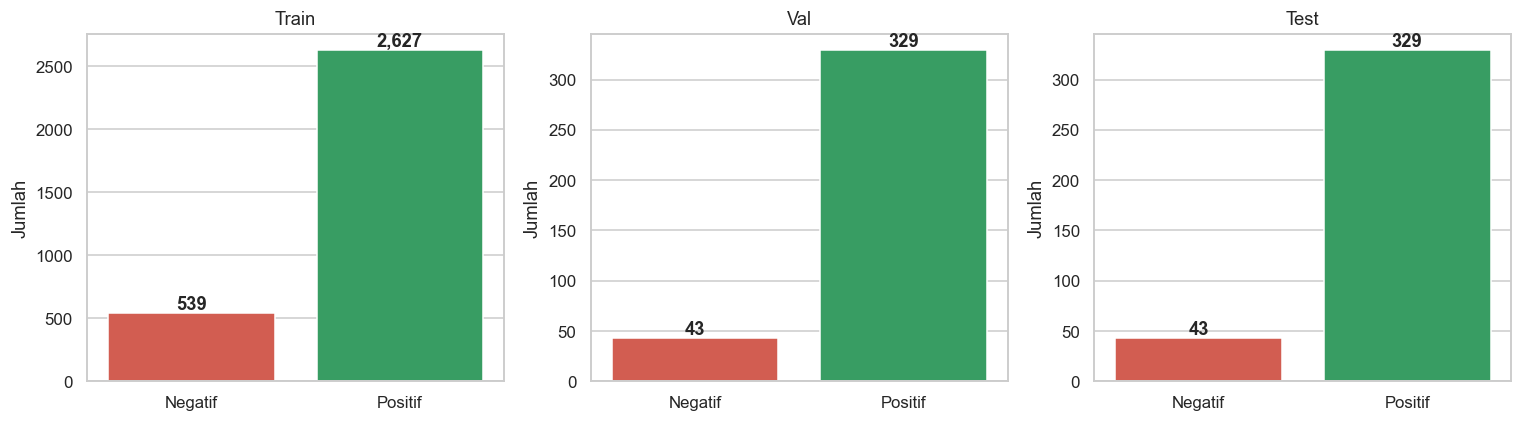

In [8]:
# ============================================================
# CELL 4.2 - EDA Split Binary
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, part) in zip(axes, [("Train", df_train), ("Val", df_val), ("Test", df_test)]):
    counts = part["label"].value_counts().reindex([0, 1], fill_value=0)
    sns.barplot(x=[LABEL_NAMES[i] for i in counts.index], y=counts.values, ax=ax, palette=[LABEL_COLORS[0], LABEL_COLORS[1]])
    ax.set_title(name)
    ax.set_ylabel("Jumlah")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "split_distribution_binary.png", dpi=150, bbox_inches="tight")
plt.show()


EDA - TRAIN BALANCED / AFTER AUGMENTATION
Train: 3,166 | Val: 372 | Test: 372


,sentimen,count,mean,median,min,max
0,Negatif,539,9.70,6.0,1,106
1,Positif,2627,10.07,6.0,1,99


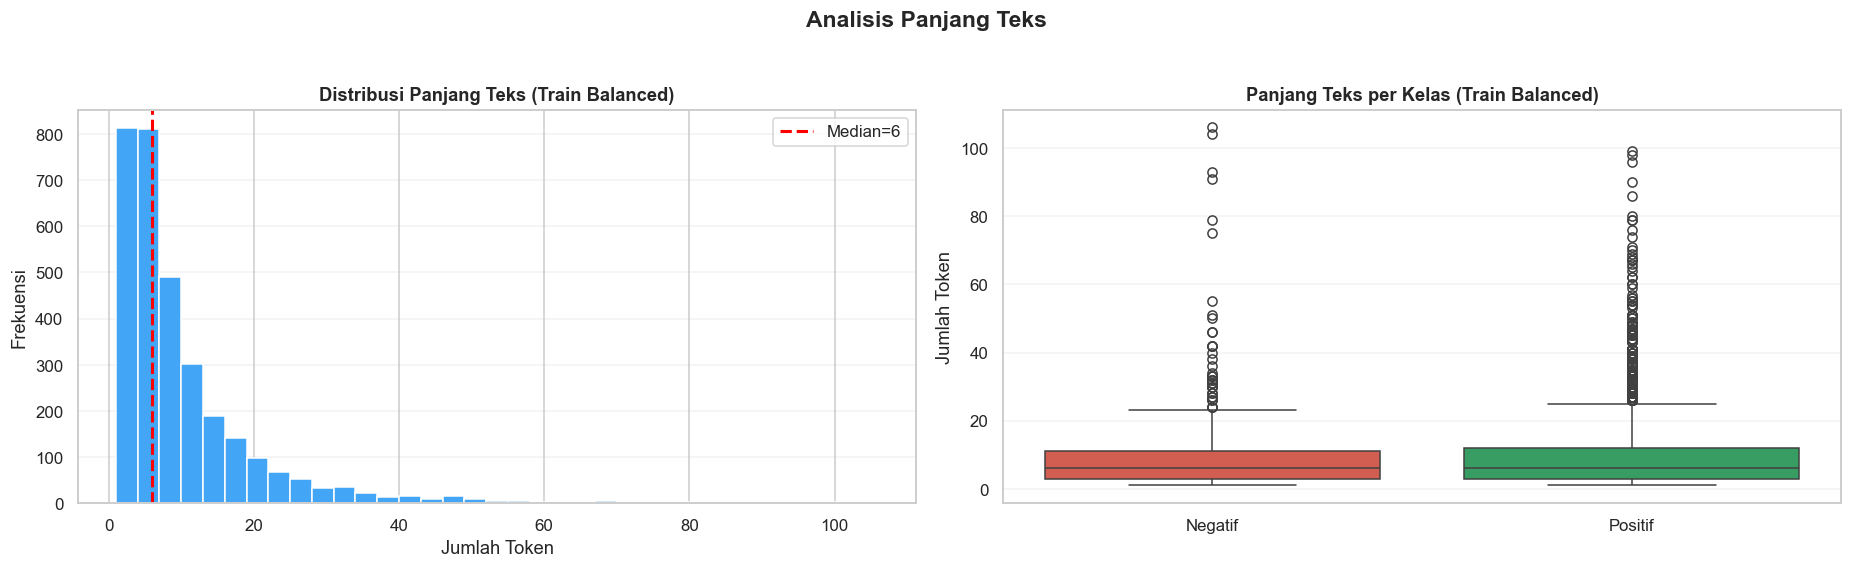

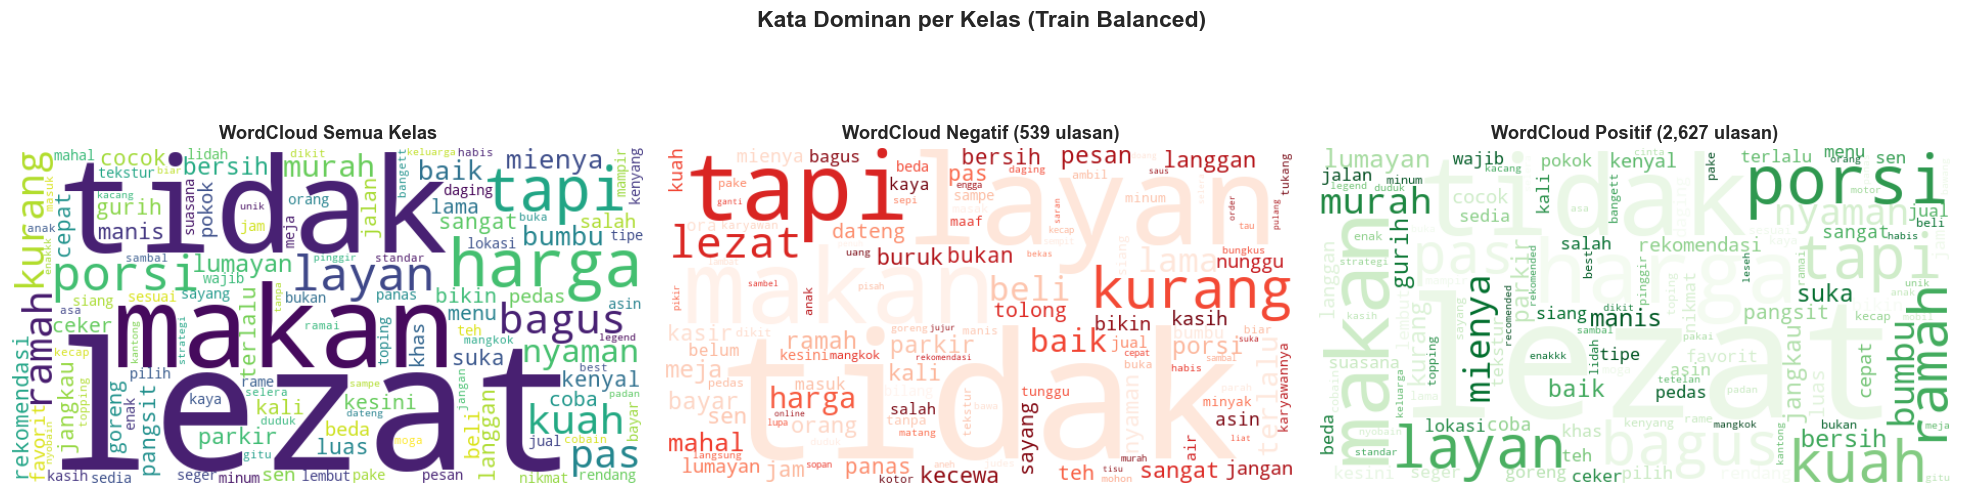

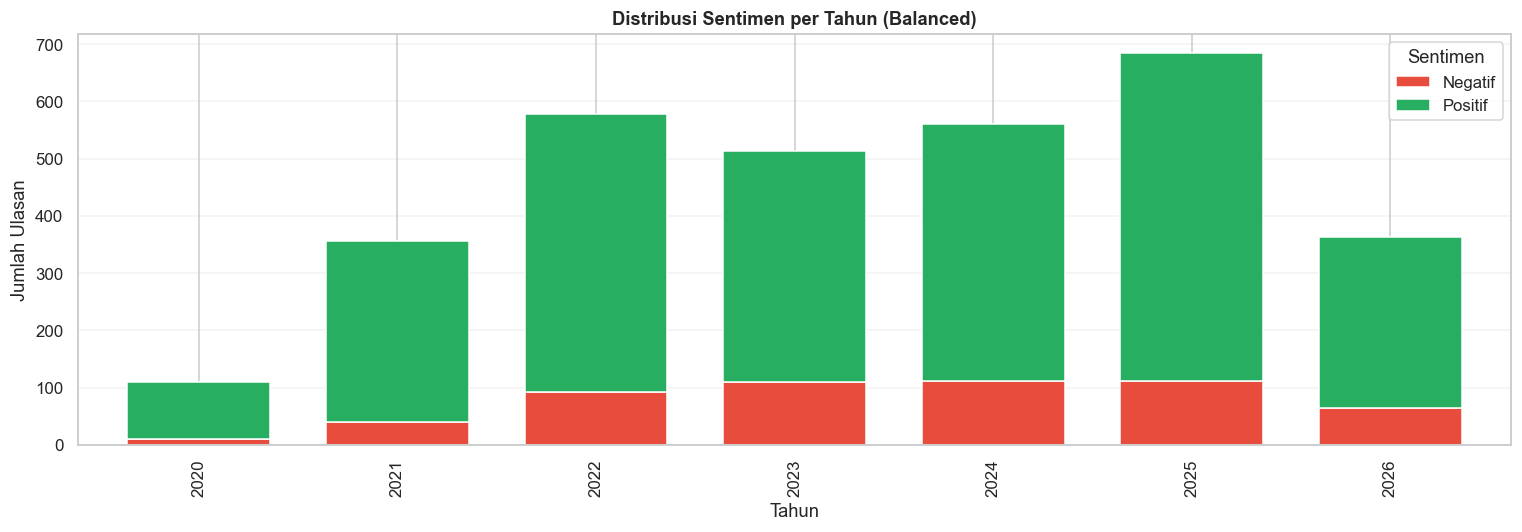

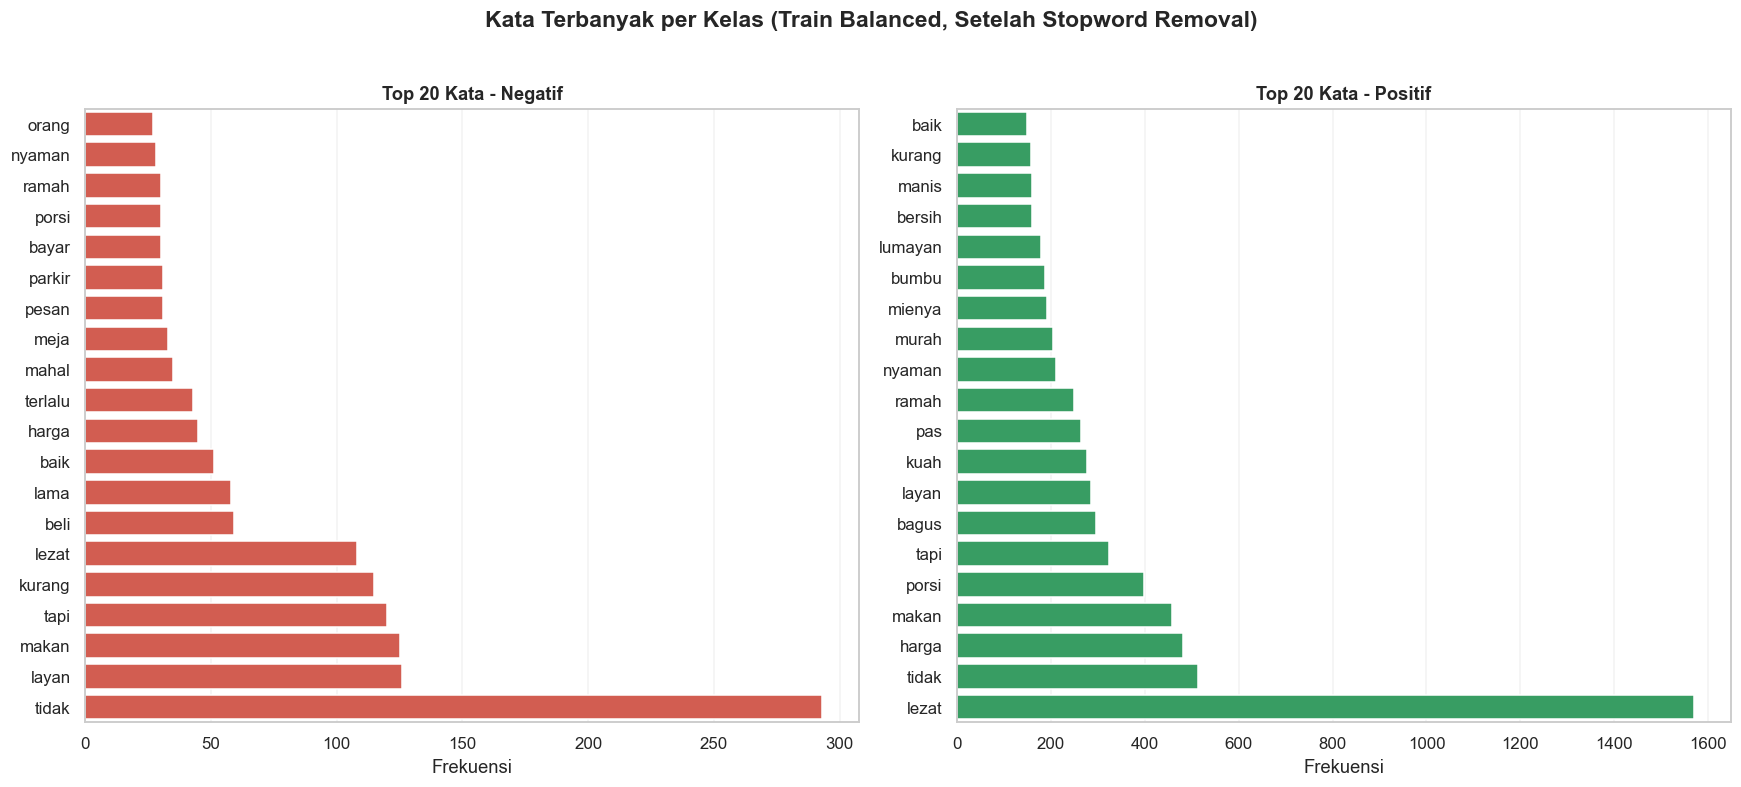

EDA outputs disimpan ke: output\geo_sentiment_fix


In [32]:
# ============================================================
# CELL 4.3 - EDA Lengkap Train Balanced / After Augmentation
# ============================================================
if "df_train" not in globals() or "df_val" not in globals() or "df_test" not in globals():
    raise RuntimeError("Split data belum tersedia. Jalankan CELL 4.1 dan augmentasi terlebih dahulu.")

df_train_eda = df_train.copy()
df_train_eda["token_len"] = df_train_eda["text_ml"].fillna("").astype(str).str.split().str.len()
df_train_eda["sentimen"] = df_train_eda["label"].map(LABEL_NAMES)

print("=" * 90)
print("EDA - TRAIN BALANCED / AFTER AUGMENTATION")
print("=" * 90)
print(f"Train: {len(df_train_eda):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")
display(
    df_train_eda.groupby("sentimen")["token_len"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
    .reset_index()
)

# 1) Analisis panjang teks.
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
median_len = int(df_train_eda["token_len"].median())
axes[0].hist(df_train_eda["token_len"], bins=35, color="#42A5F5", edgecolor="white")
axes[0].axvline(median_len, color="red", linestyle="--", linewidth=2, label=f"Median={median_len}")
axes[0].set_title("Distribusi Panjang Teks (Train Balanced)", fontweight="bold")
axes[0].set_xlabel("Jumlah Token")
axes[0].set_ylabel("Frekuensi")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

sns.boxplot(
    data=df_train_eda,
    x="sentimen",
    y="token_len",
    order=["Negatif", "Positif"],
    palette=[LABEL_COLORS[0], LABEL_COLORS[1]],
    ax=axes[1],
)
axes[1].set_title("Panjang Teks per Kelas (Train Balanced)", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Jumlah Token")
axes[1].grid(axis="y", alpha=0.25)
plt.suptitle("Analisis Panjang Teks", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_text_length_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Helper token EDA.
EDA_EXTRA_STOPWORDS = {
    "mie", "ayam", "mi", "bakso", "pwt", "purwokerto", "tempat", "sini",
    "nya", "yg", "yang", "aja", "sih", "deh", "banget", "sekali",
}
try:
    EDA_STOPWORDS = set(ID_STOPWORDS) | EDA_EXTRA_STOPWORDS
except Exception:
    EDA_STOPWORDS = EDA_EXTRA_STOPWORDS

def tokens_for_eda(series):
    tokens = []
    for text in series.fillna("").astype(str):
        for tok in text.split():
            tok = tok.strip().lower()
            if len(tok) <= 2:
                continue
            if tok in EDA_STOPWORDS:
                continue
            tokens.append(tok)
    return tokens

tokens_all = tokens_for_eda(df_train_eda["text_ml"])
tokens_neg = tokens_for_eda(df_train_eda.loc[df_train_eda["label"] == 0, "text_ml"])
tokens_pos = tokens_for_eda(df_train_eda.loc[df_train_eda["label"] == 1, "text_ml"])

# 2) WordCloud semua kelas dan per kelas.
wc_specs = [
    ("WordCloud Semua Kelas", tokens_all, "viridis"),
    (f"WordCloud Negatif ({(df_train_eda['label'] == 0).sum():,} ulasan)", tokens_neg, "Reds"),
    (f"WordCloud Positif ({(df_train_eda['label'] == 1).sum():,} ulasan)", tokens_pos, "Greens"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, toks, cmap) in zip(axes, wc_specs):
    corpus = " ".join(toks)
    if corpus.strip():
        wc = WordCloud(
            width=620,
            height=330,
            background_color="white",
            colormap=cmap,
            max_words=120,
            collocations=False,
            random_state=RANDOM_STATE,
        ).generate(corpus)
        ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontweight="bold")
    ax.axis("off")
plt.suptitle("Kata Dominan per Kelas (Train Balanced)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_wordcloud_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

# 3) Distribusi sentimen per tahun.
df_temporal_eda = df_train_eda.copy()
date_col = next((c for c in ["review_date", "posted_at", "_year"] if c in df_temporal_eda.columns), None)
if date_col:
    if date_col == "_year":
        df_temporal_eda["year_eda"] = pd.to_numeric(df_temporal_eda["_year"], errors="coerce")
    else:
        df_temporal_eda["year_eda"] = pd.to_datetime(df_temporal_eda[date_col], errors="coerce").dt.year
    df_year = (
        df_temporal_eda.dropna(subset=["year_eda"])
        .assign(year_eda=lambda d: d["year_eda"].astype(int))
        .groupby(["year_eda", "label"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=[0, 1], fill_value=0)
    )
    if len(df_year):
        ax = df_year.rename(columns=LABEL_NAMES).plot(
            kind="bar",
            stacked=True,
            figsize=(14, 5),
            color=[LABEL_COLORS[0], LABEL_COLORS[1]],
            width=0.72,
        )
        ax.set_title("Distribusi Sentimen per Tahun (Balanced)", fontweight="bold")
        ax.set_xlabel("Tahun")
        ax.set_ylabel("Jumlah Ulasan")
        ax.legend(title="Sentimen")
        ax.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "eda_sentiment_by_year.png", dpi=150, bbox_inches="tight")
        plt.show()
else:
    print("[EDA] Kolom tanggal/tahun tidak tersedia, plot temporal dilewati.")

# 4) Top 20 kata per kelas.
def top_words_frame(tokens, label_name, n=20):
    return pd.DataFrame(Counter(tokens).most_common(n), columns=["kata", "frekuensi"]).assign(sentimen=label_name)

top_neg = top_words_frame(tokens_neg, "Negatif")
top_pos = top_words_frame(tokens_pos, "Positif")
df_top_words = pd.concat([top_neg, top_pos], ignore_index=True)
df_top_words.to_csv(OUTPUT_DIR / "eda_top_words_by_class.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, top_df, title, color in [
    (axes[0], top_neg, "Top 20 Kata - Negatif", LABEL_COLORS[0]),
    (axes[1], top_pos, "Top 20 Kata - Positif", LABEL_COLORS[1]),
]:
    plot_df = top_df.sort_values("frekuensi", ascending=True)
    sns.barplot(data=plot_df, x="frekuensi", y="kata", color=color, ax=ax)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Frekuensi")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
plt.suptitle("Kata Terbanyak per Kelas (Train Balanced, Setelah Stopword Removal)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_top_words_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"EDA outputs disimpan ke: {OUTPUT_DIR}")

## 3. Training OPT IndoBERT


In [9]:
# ============================================================
# CELL 5.1 - Helper Evaluasi, Class Weight, dan Threshold
# ============================================================
NEG_CLASS_BOOST = 3.25
THRESHOLD_GRID = np.round(np.arange(0.20, 0.96, 0.01), 2)
TARGET_VAL_RECALL_NEG = 0.90

def make_adjusted_class_weight(y, neg_boost=NEG_CLASS_BOOST):
    y_arr = np.asarray(y).astype(int)
    labels = np.array(sorted(np.unique(y_arr)))
    base = compute_class_weight(class_weight="balanced", classes=labels, y=y_arr)
    weights = {int(lbl): float(w) for lbl, w in zip(labels, base)}
    if 0 in weights:
        weights[0] *= neg_boost
    mean_w = np.mean(list(weights.values()))
    return {k: v / mean_w for k, v in weights.items()}

def get_pos_scores(y_prob):
    arr = np.asarray(y_prob)
    if arr.ndim == 1:
        return arr
    return arr[:, 1] if arr.shape[1] > 1 else arr[:, 0]

def predict_with_threshold(y_prob, threshold):
    return (get_pos_scores(y_prob) >= threshold).astype(int)

def binary_metrics(y_true, y_pred, y_prob=None):
    pos_scores = None if y_prob is None else get_pos_scores(y_prob)
    try:
        roc = roc_auc_score(y_true, pos_scores) if pos_scores is not None else float("nan")
    except Exception:
        roc = float("nan")
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_pos": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_neg": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc": roc,
    }

def tune_threshold_focus_neg(y_true_val, y_prob_val, grid=THRESHOLD_GRID, target_recall_neg=TARGET_VAL_RECALL_NEG):
    y_true_val = np.asarray(y_true_val).astype(int)
    rows = []
    for th in grid:
        y_pred = predict_with_threshold(y_prob_val, th)
        m = binary_metrics(y_true_val, y_pred, y_prob_val)
        # Objective dibuat lebih agresif ke kelas negatif.
        # Higher threshold -> cenderung menaikkan Recall-NEG, tetapi bisa menurunkan Recall-POS.
        score = (0.55 * m["recall_neg"]) + (0.35 * m["macro_f1"]) + (0.10 * m["recall_pos"])
        if m["recall_neg"] < target_recall_neg:
            score -= 0.40 * (target_recall_neg - m["recall_neg"])
        rows.append({
            "threshold": float(th),
            "score": float(score),
            **{k: float(v) for k, v in m.items()},
        })
    df_thr = pd.DataFrame(rows)
    eligible = df_thr[df_thr["recall_neg"] >= target_recall_neg].copy()
    rank_df = eligible if len(eligible) else df_thr
    rank_df = rank_df.sort_values(["score", "recall_neg", "macro_f1"], ascending=False).reset_index(drop=True)
    best_threshold = float(rank_df.iloc[0]["threshold"])
    return best_threshold, df_thr.sort_values(["score", "recall_neg", "macro_f1"], ascending=False).reset_index(drop=True)

def metrics_from_threshold(y_true, y_prob, threshold):
    y_pred = predict_with_threshold(y_prob, threshold)
    return binary_metrics(y_true, y_pred, y_prob), y_pred

def print_binary_report(title, y_true, y_pred, y_prob=None):
    m = binary_metrics(y_true, y_pred, y_prob)
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    print(f"Accuracy    : {m['accuracy']:.4f}")
    print(f"Recall-NEG  : {m['recall_neg']:.4f}")
    print(f"Recall-POS  : {m['recall_pos']:.4f}")
    print(f"Macro-F1    : {m['macro_f1']:.4f}")
    print(f"Weighted-F1 : {m['weighted_f1']:.4f}")
    print(f"ROC-AUC     : {m['roc_auc']:.4f}")
    print("-" * 70)
    print(classification_report(y_true, y_pred, target_names=["Negatif", "Positif"], zero_division=0))
    return m

ALL_RESULTS = {}
print("[OK] Helper evaluasi dan threshold siap.")


[OK] Helper evaluasi dan threshold siap.


In [10]:
# ============================================================
# CELL 6.1 - OPT IndoBERT: Weighted/Focal Loss + Early Stop + Threshold
# ============================================================
RUN_OPT_INDOBERT = True

# Konfigurasi optimasi kelas negatif.
OPT_BERT_EPOCHS = 8
OPT_BERT_PATIENCE = 3
OPT_BERT_MAX_LEN = 160
OPT_BERT_TRAIN_BATCH = 8
OPT_BERT_EVAL_BATCH = 16
OPT_BERT_LR = 2e-5
OPT_BERT_WEIGHT_DECAY = 0.02
OPT_BERT_WARMUP_RATIO = 0.12
OPT_BERT_FOCAL_GAMMA = 1.5  # set 0 untuk Weighted CrossEntropy biasa.

if RUN_OPT_INDOBERT:
    if not TORCH_OK:
        raise RuntimeError("PyTorch/Transformers belum tersedia.")
    import inspect

    tokenizer_opt = AutoTokenizer.from_pretrained(INDOBERT_MODEL)
    bert_id2label = {0: "Negatif", 1: "Positif"}
    bert_label2id = {v: k for k, v in bert_id2label.items()}
    model_opt = AutoModelForSequenceClassification.from_pretrained(
        INDOBERT_MODEL,
        num_labels=2,
        id2label=bert_id2label,
        label2id=bert_label2id,
        ignore_mismatched_sizes=True,
    )

    class SentimentDatasetOpt(TorchDataset):
        def __init__(self, texts, labels, tokenizer, max_len=160):
            self.texts = list(texts)
            self.labels = list(labels)
            self.tokenizer = tokenizer
            self.max_len = max_len
        def __len__(self):
            return len(self.texts)
        def __getitem__(self, idx):
            enc = self.tokenizer(
                str(self.texts[idx]),
                add_special_tokens=True,
                max_length=self.max_len,
                padding="max_length",
                truncation=True,
                return_tensors="pt",
            )
            return {
                "input_ids": enc["input_ids"].flatten(),
                "attention_mask": enc["attention_mask"].flatten(),
                "labels": torch.tensor(int(self.labels[idx]), dtype=torch.long),
            }

    train_dataset = SentimentDatasetOpt(df_train["text_bert"], df_train["label"], tokenizer_opt, OPT_BERT_MAX_LEN)
    val_dataset = SentimentDatasetOpt(df_val["text_bert"], df_val["label"], tokenizer_opt, OPT_BERT_MAX_LEN)
    test_dataset = SentimentDatasetOpt(df_test["text_bert"], df_test["label"], tokenizer_opt, OPT_BERT_MAX_LEN)

    cw_bert = make_adjusted_class_weight(df_train["label"].tolist(), neg_boost=NEG_CLASS_BOOST)
    class_weights_tensor = torch.tensor([cw_bert.get(0, 1.0), cw_bert.get(1, 1.0)], dtype=torch.float)

    class WeightedFocalTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            weights = class_weights_tensor.to(logits.device)
            ce_loss = F.cross_entropy(logits, labels, weight=weights, reduction="none")
            if OPT_BERT_FOCAL_GAMMA and OPT_BERT_FOCAL_GAMMA > 0:
                pt = torch.exp(-ce_loss)
                loss = (((1 - pt) ** OPT_BERT_FOCAL_GAMMA) * ce_loss).mean()
            else:
                loss = ce_loss.mean()
            return (loss, outputs) if return_outputs else loss

    class InMemoryBestAndEarlyStop(TrainerCallback):
        def __init__(self, patience=3, metric_name="eval_objective", min_delta=1e-4):
            self.patience = patience
            self.metric_name = metric_name
            self.min_delta = min_delta
            self.best = None
            self.bad_epochs = 0
            self.best_state = None
        def on_evaluate(self, args, state, control, metrics=None, model=None, **kwargs):
            if not metrics or self.metric_name not in metrics or model is None:
                return control
            current = float(metrics[self.metric_name])
            if self.best is None or current > self.best + self.min_delta:
                self.best = current
                self.bad_epochs = 0
                self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                self.bad_epochs += 1
                if self.bad_epochs >= self.patience:
                    control.should_training_stop = True
            return control
        def on_train_end(self, args, state, control, model=None, **kwargs):
            if self.best_state is not None and model is not None:
                model.load_state_dict(self.best_state)
                print(f"[EarlyStop] Restored best in-memory weights, best {self.metric_name}={self.best:.4f}")
            return control

    def compute_metrics_opt(pred):
        labels = pred.label_ids.astype(int)
        preds = pred.predictions.argmax(-1)
        rec_neg = recall_score(labels, preds, pos_label=0, zero_division=0)
        rec_pos = recall_score(labels, preds, pos_label=1, zero_division=0)
        macro = f1_score(labels, preds, average="macro", zero_division=0)
        return {
            "accuracy": accuracy_score(labels, preds),
            "macro_f1": macro,
            "recall_neg": rec_neg,
            "recall_pos": rec_pos,
            "objective": (0.55 * rec_neg) + (0.35 * macro) + (0.10 * rec_pos),
        }

    ta_params = inspect.signature(TrainingArguments.__init__).parameters
    training_kwargs = {
        "output_dir": str(MODEL_DIR / "indobert_opt_recall_neg"),
        "num_train_epochs": OPT_BERT_EPOCHS,
        "per_device_train_batch_size": OPT_BERT_TRAIN_BATCH,
        "per_device_eval_batch_size": OPT_BERT_EVAL_BATCH,
        "learning_rate": OPT_BERT_LR,
        "warmup_ratio": OPT_BERT_WARMUP_RATIO,
        "weight_decay": OPT_BERT_WEIGHT_DECAY,
        "logging_dir": str(OUTPUT_DIR / "logs"),
        "logging_steps": 20,
        "save_strategy": "no",
        "load_best_model_at_end": False,
        "fp16": torch.cuda.is_available(),
        "report_to": "none",
    }
    if "eval_strategy" in ta_params:
        training_kwargs["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in ta_params:
        training_kwargs["evaluation_strategy"] = "epoch"
    training_kwargs = {k: v for k, v in training_kwargs.items() if k in ta_params}

    trainer_opt = WeightedFocalTrainer(
        model=model_opt,
        args=TrainingArguments(**training_kwargs),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics_opt,
        callbacks=[InMemoryBestAndEarlyStop(patience=OPT_BERT_PATIENCE)],
    )

    print(f"[OPT-BERT] class_weight={cw_bert}")
    print(f"[OPT-BERT] focal_gamma={OPT_BERT_FOCAL_GAMMA} | target_val_recall_neg={TARGET_VAL_RECALL_NEG}")
    print("[OPT-BERT] checkpoint_save=OFF, best weights disimpan sementara di memory")

    t0 = time.perf_counter()
    trainer_opt.train()
    train_time = time.perf_counter() - t0

    val_pred = trainer_opt.predict(val_dataset)
    test_pred = trainer_opt.predict(test_dataset)
    y_prob_val = F.softmax(torch.tensor(val_pred.predictions), dim=-1).numpy()
    y_prob_test = F.softmax(torch.tensor(test_pred.predictions), dim=-1).numpy()

    threshold, df_thresholds = tune_threshold_focus_neg(df_val["label"].tolist(), y_prob_val)
    val_metrics, y_pred_val = metrics_from_threshold(df_val["label"].tolist(), y_prob_val, threshold)
    test_metrics, y_pred_test = metrics_from_threshold(df_test["label"].tolist(), y_prob_test, threshold)

    model_name = "OPT IndoBERT + weighted/focal loss + early_stop + threshold"
    ALL_RESULTS = {
        model_name: {
            "model": trainer_opt,
            "tokenizer": tokenizer_opt,
            "val": val_metrics,
            "test": test_metrics,
            "y_pred_val": y_pred_val,
            "y_pred_test": y_pred_test,
            "y_prob_val": y_prob_val,
            "y_prob_test": y_prob_test,
            "threshold": threshold,
            "threshold_table": df_thresholds,
            "train_time": train_time,
            "class_weight": cw_bert,
            "notes": "Negative class boost + focal weighted loss + in-memory early stopping + threshold tuned for Recall-NEG.",
        }
    }

    # Simpan model dan threshold supaya inference ulang konsisten.
    save_dir = MODEL_DIR / "indobert_opt_recall_neg"
    save_dir.mkdir(parents=True, exist_ok=True)
    trainer_opt.model.save_pretrained(save_dir)
    tokenizer_opt.save_pretrained(save_dir)
    with open(save_dir / "threshold_config.json", "w", encoding="utf-8") as f:
        json.dump({
            "threshold": threshold,
            "label_names": LABEL_NAMES,
            "class_weight": cw_bert,
            "target_val_recall_neg": TARGET_VAL_RECALL_NEG,
            "neg_class_boost": NEG_CLASS_BOOST,
            "focal_gamma": OPT_BERT_FOCAL_GAMMA,
        }, f, ensure_ascii=False, indent=2)

    print(f"\n[OPT-BERT] Training selesai dalam {train_time:.1f}s")
    print(f"[OPT-BERT] Threshold terpilih: {threshold:.2f}")
    print(f"[OPT-BERT] Model disimpan: {save_dir}")
else:
    print("[OPT-BERT] Dilewati.")


[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `3`.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: mdhugol/indonesia-bert-sentiment-classification
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


[OPT-BERT] class_weight={0: np.float64(1.8812350235491777), 1: np.float64(0.11876497645082215)}
[OPT-BERT] focal_gamma=1.5 | target_val_recall_neg=0.9
[OPT-BERT] checkpoint_save=OFF, best weights disimpan sementara di memory


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Recall Neg,Recall Pos,Objective
1,0.007362,0.007295,0.873656,0.784847,1.000000,0.857143,0.910411
2,0.011581,0.008430,0.865591,0.775058,1.000000,0.848024,0.906073
3,0.000787,0.012161,0.935484,0.867984,0.953488,0.933131,0.921526
4,0.000242,0.065139,0.959677,0.893785,0.744186,0.987842,0.820911
5,0.000149,0.039923,0.967742,0.922672,0.883721,0.978723,0.906854
6,0.000006,0.053017,0.967742,0.919481,0.837209,0.984802,0.880764


[EarlyStop] Restored best in-memory weights, best eval_objective=0.9215


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


[OPT-BERT] Training selesai dalam 529.9s
[OPT-BERT] Threshold terpilih: 0.68
[OPT-BERT] Model disimpan: model\geo_sentiment_fix\indobert_opt_recall_neg


## 4. Evaluasi Model


In [11]:
# ============================================================
# CELL 7.1 - Ringkasan Evaluasi IndoBERT
# ============================================================
if "ALL_RESULTS" not in globals() or not ALL_RESULTS:
    raise RuntimeError("ALL_RESULTS belum tersedia. Jalankan CELL 6.1 terlebih dahulu.")

rows = []
for model_name, res in ALL_RESULTS.items():
    t = res["test"]
    v = res["val"]
    rows.append({
        "Model": model_name,
        "Threshold": round(res["threshold"], 3),
        "Val Recall-NEG": round(v["recall_neg"], 4),
        "Val Macro-F1": round(v["macro_f1"], 4),
        "Test Accuracy": round(t["accuracy"], 4),
        "Test Recall-NEG": round(t["recall_neg"], 4),
        "Test Recall-POS": round(t["recall_pos"], 4),
        "Test Macro-F1": round(t["macro_f1"], 4),
        "Test Weighted-F1": round(t["weighted_f1"], 4),
        "Test ROC-AUC": round(t["roc_auc"], 4),
        "Train Time (s)": round(res["train_time"], 1),
        "Notes": res["notes"],
    })

df_results = pd.DataFrame(rows)
df_results.to_csv(OUTPUT_DIR / "indobert_optimized_results.csv", index=False, encoding="utf-8-sig")
display(df_results)

best_name = df_results.iloc[0]["Model"]
best_res = ALL_RESULTS[best_name]
print_binary_report(
    "TEST REPORT - OPT IndoBERT",
    df_test["label"].to_numpy(),
    best_res["y_pred_test"],
    best_res["y_prob_test"],
)


,Model,Threshold,Val Recall-NEG,Val Macro-F1,Test Accuracy,Test Recall-NEG,Test Recall-POS,Test Macro-F1,Test Weighted-F1,Test ROC-AUC,Train Time (s),Notes
0,OPT IndoBERT + weighted/focal loss + early_sto...,0.68,1.0,0.855,0.9086,0.9767,0.8997,0.8288,0.9187,0.9833,529.9,Negative class boost + focal weighted loss + i...



TEST REPORT - OPT IndoBERT
Accuracy    : 0.9086
Recall-NEG  : 0.9767
Recall-POS  : 0.8997
Macro-F1    : 0.8288
Weighted-F1 : 0.9187
ROC-AUC     : 0.9833
----------------------------------------------------------------------
              precision    recall  f1-score   support

     Negatif       0.56      0.98      0.71        43
     Positif       1.00      0.90      0.95       329

    accuracy                           0.91       372
   macro avg       0.78      0.94      0.83       372
weighted avg       0.95      0.91      0.92       372



{'accuracy': 0.9086021505376344,
 'precision': 0.9966329966329966,
 'recall_pos': 0.8996960486322189,
 'recall_neg': 0.9767441860465116,
 'macro_f1': 0.8287756538690637,
 'weighted_f1': 0.9186590320076906,
 'roc_auc': 0.9833180179543365}

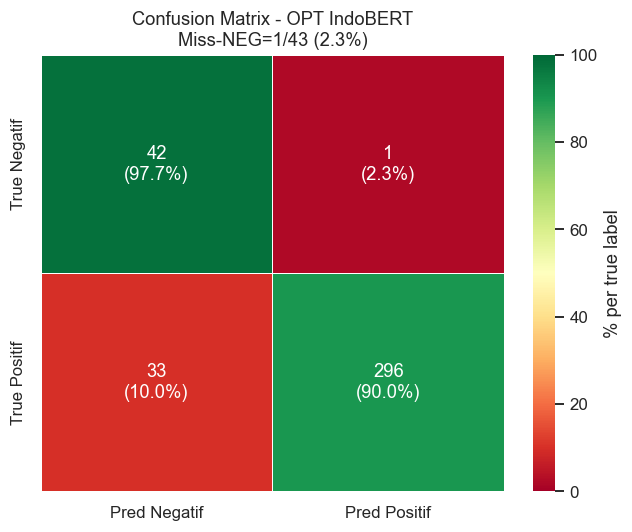

In [12]:
# ============================================================
# CELL 7.2 - Confusion Matrix
# ============================================================
best_name = df_results.iloc[0]["Model"]
best_res = ALL_RESULTS[best_name]
y_true = df_test["label"].to_numpy()
y_pred = best_res["y_pred_test"]

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
cm_pct = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100
annot = np.array([[f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(2)] for i in range(2)])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_pct,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    xticklabels=["Pred Negatif", "Pred Positif"],
    yticklabels=["True Negatif", "True Positif"],
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "% per true label"},
)
miss_neg = int(cm[0, 1])
neg_total = int(cm[0].sum())
plt.title(f"Confusion Matrix - OPT IndoBERT\nMiss-NEG={miss_neg}/{neg_total} ({miss_neg / max(neg_total, 1) * 100:.1f}%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_indobert_opt.png", dpi=150, bbox_inches="tight")
plt.show()


,threshold,score,accuracy,precision,recall_pos,recall_neg,macro_f1,weighted_f1,roc_auc
0,0.68,0.940729,0.924731,1.000000,0.914894,1.000000,0.854971,0.932302,0.990493
1,0.69,0.940729,0.924731,1.000000,0.914894,1.000000,0.854971,0.932302,0.990493
2,0.70,0.940729,0.924731,1.000000,0.914894,1.000000,0.854971,0.932302,0.990493
3,0.71,0.940729,0.924731,1.000000,0.914894,1.000000,0.854971,0.932302,0.990493
4,0.72,0.940729,0.924731,1.000000,0.914894,1.000000,0.854971,0.932302,0.990493
5,0.73,0.933870,0.913978,1.000000,0.902736,1.000000,0.838848,0.923444,0.990493
6,0.74,0.933870,0.913978,1.000000,0.902736,1.000000,0.838848,0.923444,0.990493
7,0.75,0.933870,0.913978,1.000000,0.902736,1.000000,0.838848,0.923444,0.990493
8,0.76,0.933870,0.913978,1.000000,0.902736,1.000000,0.838848,0.923444,0.990493
9,0.77,0.932200,0.911290,1.000000,0.899696,1.000000,0.834945,0.921248,0.990493


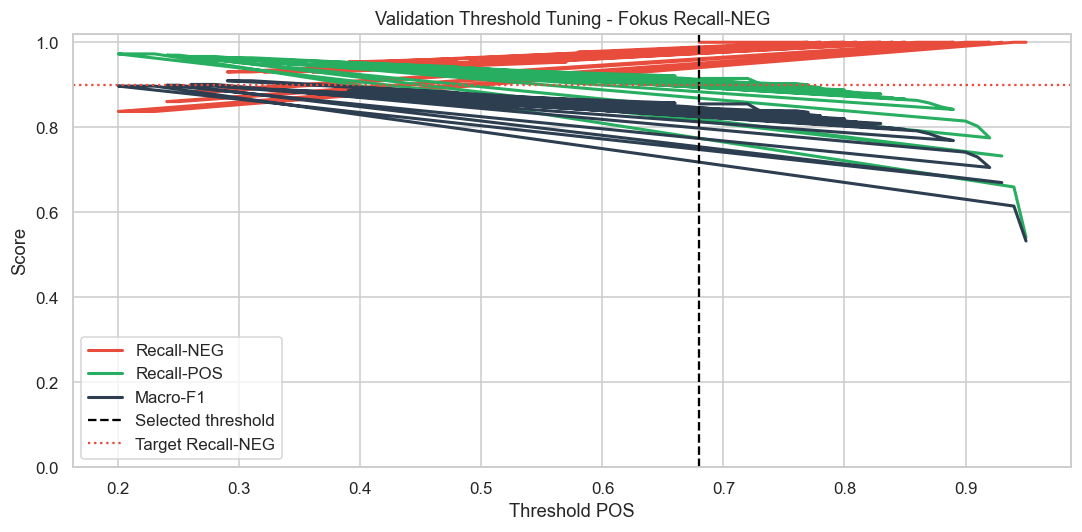

In [13]:
# ============================================================
# CELL 7.3 - Analisis Threshold
# ============================================================
best_name = df_results.iloc[0]["Model"]
df_thr = ALL_RESULTS[best_name]["threshold_table"].copy()
display(df_thr.head(15))

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(df_thr["threshold"], df_thr["recall_neg"], label="Recall-NEG", color="#E74C3C", linewidth=2)
ax1.plot(df_thr["threshold"], df_thr["recall_pos"], label="Recall-POS", color="#27AE60", linewidth=2)
ax1.plot(df_thr["threshold"], df_thr["macro_f1"], label="Macro-F1", color="#2C3E50", linewidth=2)
ax1.axvline(ALL_RESULTS[best_name]["threshold"], color="black", linestyle="--", label="Selected threshold")
ax1.axhline(TARGET_VAL_RECALL_NEG, color="#E74C3C", linestyle=":", label="Target Recall-NEG")
ax1.set_xlabel("Threshold POS")
ax1.set_ylabel("Score")
ax1.set_ylim(0, 1.02)
ax1.legend(loc="lower left")
ax1.set_title("Validation Threshold Tuning - Fokus Recall-NEG")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "threshold_tuning_recall_neg.png", dpi=150, bbox_inches="tight")
plt.show()


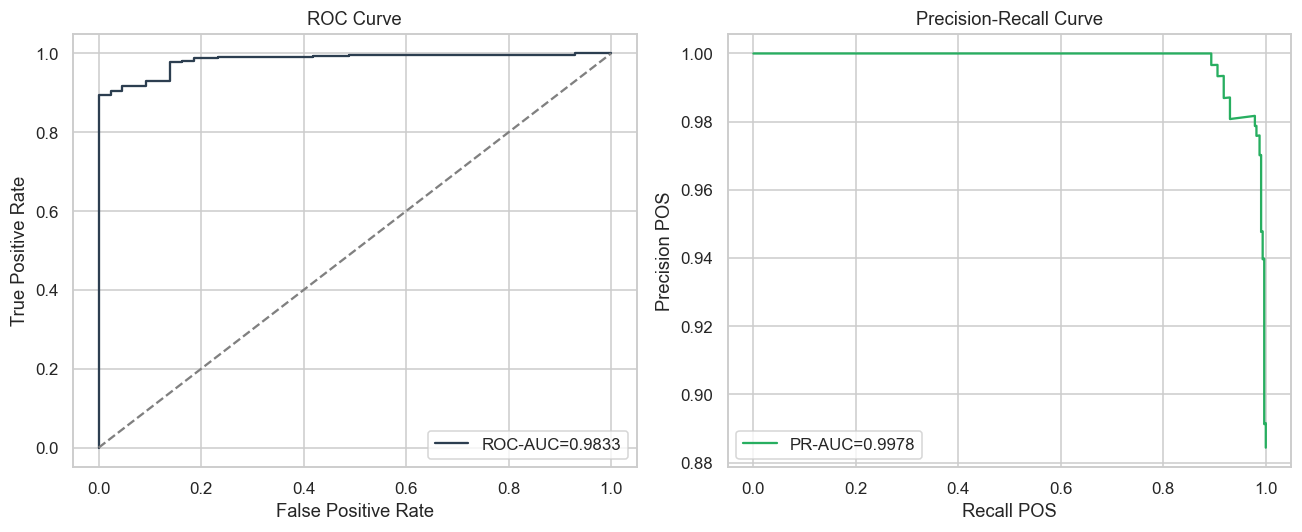

In [14]:
# ============================================================
# CELL 7.4 - ROC & Precision-Recall Curve
# ============================================================
best_name = df_results.iloc[0]["Model"]
best_res = ALL_RESULTS[best_name]
y_true = df_test["label"].to_numpy()
pos_scores = get_pos_scores(best_res["y_prob_test"])

fpr, tpr, _ = roc_curve(y_true, pos_scores)
prec, rec, _ = precision_recall_curve(y_true, pos_scores)
roc_auc_val = roc_auc_score(y_true, pos_scores)
pr_auc_val = auc(rec, prec)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, color="#2C3E50", label=f"ROC-AUC={roc_auc_val:.4f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(rec, prec, color="#27AE60", label=f"PR-AUC={pr_auc_val:.4f}")
axes[1].set_xlabel("Recall POS")
axes[1].set_ylabel("Precision POS")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_pr_indobert_opt.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
# ============================================================
# CELL 7.5 - Error Analysis: Miss-NEG
# ============================================================
best_name = df_results.iloc[0]["Model"]
best_res = ALL_RESULTS[best_name]

df_err = df_test.copy().reset_index(drop=True)
df_err["y_true"] = df_test["label"].astype(int).to_numpy()
df_err["y_pred"] = best_res["y_pred_test"]
df_err["prob_pos"] = get_pos_scores(best_res["y_prob_test"])
df_err["prob_neg"] = 1 - df_err["prob_pos"]
df_err["correct"] = df_err["y_true"] == df_err["y_pred"]

df_miss_neg = df_err[(df_err["y_true"] == 0) & (df_err["y_pred"] == 1)].copy()
df_false_neg_pos = df_err[(df_err["y_true"] == 1) & (df_err["y_pred"] == 0)].copy()

df_miss_neg.to_csv(OUTPUT_DIR / "miss_negative_samples.csv", index=False, encoding="utf-8-sig")
df_false_neg_pos.to_csv(OUTPUT_DIR / "false_negative_positive_samples.csv", index=False, encoding="utf-8-sig")

print(f"Miss-NEG (Negatif -> Positif): {len(df_miss_neg)}")
print(f"False Negative POS (Positif -> Negatif): {len(df_false_neg_pos)}")
print(f"CSV Miss-NEG: {OUTPUT_DIR / 'miss_negative_samples.csv'}")

display_cols = [c for c in ["review_text", "text_bert", "text_ml", "prob_pos", "prob_neg", "y_true", "y_pred"] if c in df_miss_neg.columns]
display(df_miss_neg.sort_values("prob_pos", ascending=False)[display_cols].head(15))

if len(df_miss_neg) > 0:
    tokens = " ".join(df_miss_neg["text_ml"].fillna("")).split()
    print("\nToken paling sering pada Miss-NEG:")
    print(Counter(tokens).most_common(20))


Miss-NEG (Negatif -> Positif): 1
False Negative POS (Positif -> Negatif): 33
CSV Miss-NEG: output\geo_sentiment_fix\miss_negative_samples.csv


,review_text,text_bert,text_ml,prob_pos,prob_neg,y_true,y_pred
51,"yummy, but lil bit overselled, considering the...",nikmat but lil bit overselled considering the ...,nikmat but lil bit overselled considering the ...,0.744935,0.255065,0,1



Token paling sering pada Miss-NEG:
[('but', 2), ('nikmat', 1), ('lil', 1), ('bit', 1), ('overselled', 1), ('considering', 1), ('the', 1), ('price', 1), ('dat', 1), ('relatively', 1), ('high', 1), ('this', 1), ('type', 1), ('of', 1), ('noodle', 1), ('delicious', 1), ('not', 1), ('really', 1), ('impresive', 1), ('imo', 1)]


EVALUASI LANJUTAN - OPT IndoBERT


,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_neg,recall_neg,f1_neg,precision_pos,recall_pos,...,roc_auc,pr_auc_pos,mcc,cohen_kappa,brier_pos,log_loss,tn,fp_neg_to_pos,fn_pos_to_neg,tp
0,Validation,0.924731,0.957447,0.854971,0.932302,0.605634,1.000000,0.754386,1.000000,0.914894,...,0.990493,0.998748,0.744373,0.713074,0.044087,0.162430,43,0,28,301
1,Test,0.908602,0.938220,0.828776,0.918659,0.560000,0.976744,0.711864,0.996633,0.899696,...,0.983318,0.997838,0.698467,0.662234,0.055978,0.198568,42,1,33,296


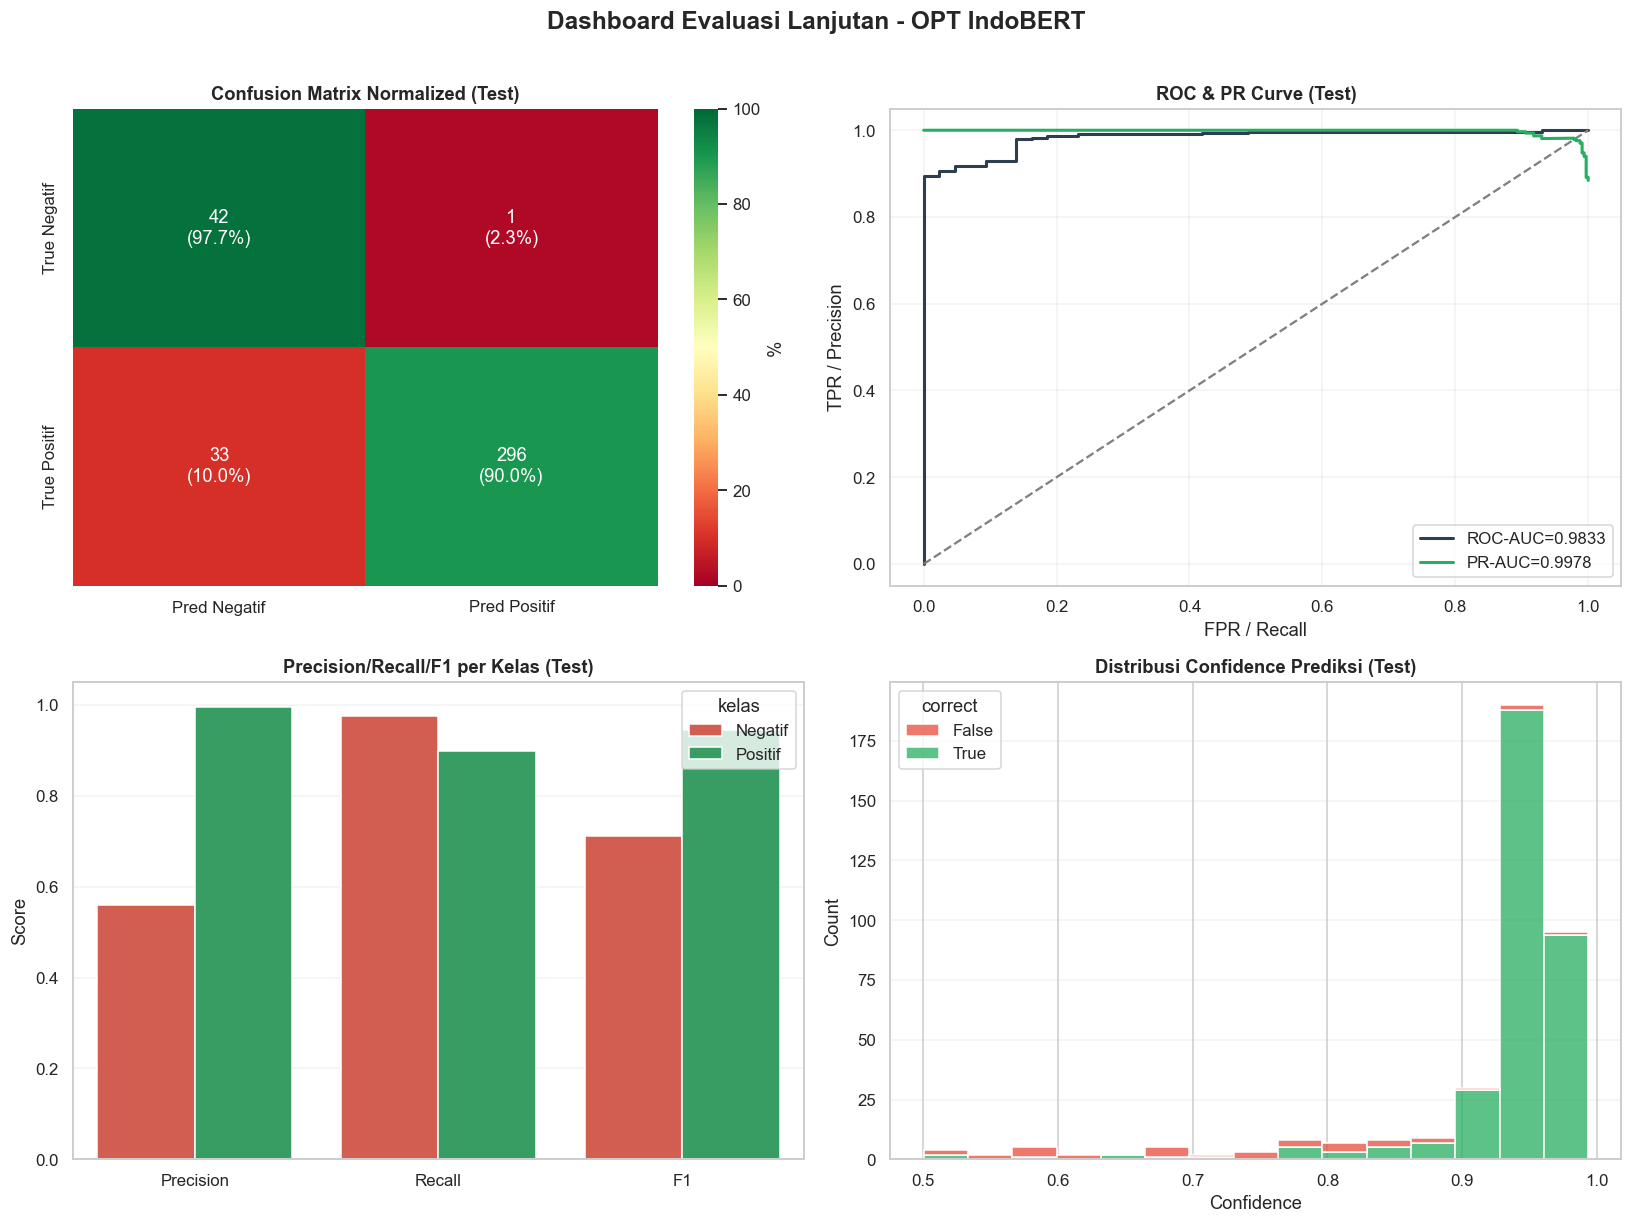


Ringkasan confidence:


,confidence_bin,correct,jumlah
0,"(-0.001, 0.55]",False,3
1,"(-0.001, 0.55]",True,2
2,"(0.55, 0.65]",False,7
3,"(0.55, 0.65]",True,2
4,"(0.65, 0.75]",False,6
5,"(0.65, 0.75]",True,3
6,"(0.75, 0.85]",False,11
7,"(0.75, 0.85]",True,10
8,"(0.85, 0.95]",False,5
9,"(0.85, 0.95]",True,116



High-confidence errors:


,review_text,text_bert,y_true,y_pred,error_type,prob_neg,prob_pos,confidence
348,Sementara di hati saya ini no 1..,sementara di hati saya ini no 1,1,0,False-Neg-POS,0.991603,0.008397,0.991603
108,"Penasaran krn beberapa kali liat di sosmed, tp...",penasaran karena beberapa kali liat di sosmed ...,1,0,False-Neg-POS,0.957198,0.042802,0.957198
111,"Karena banyak yg review, akhirnya coba2 ke sin...",karena banyak yang review akhirnya coba2 ke si...,1,0,False-Neg-POS,0.948010,0.051990,0.948010
41,"Bapaknya ga gendut.. kecil gitu badannya, ged...",bapaknya tidak gendut kecil gitu badannya gede...,1,0,False-Neg-POS,0.920790,0.079210,0.920790
47,mie ayamnya enaak. bumbu rendangnya juga nampo...,mie ayamnya enaak bumbu rendangnya juga nampol...,1,0,False-Neg-POS,0.889816,0.110184,0.889816
110,Tetelannya banyak gajihnya,tetelannya banyak gajihnya,1,0,False-Neg-POS,0.882276,0.117724,0.882276
127,Sudah merasakan mie ayam ini sejak dulu masih ...,sudah merasakan mie ayam ini sejak dulu masih ...,1,0,False-Neg-POS,0.857649,0.142351,0.857649
337,Yang review pada lucu🤣 beli di mie ayam Kamand...,yang review pada lucu beli di mie ayam kamanda...,1,0,False-Neg-POS,0.837686,0.162314,0.837686
306,Mie nya Enaaakkk.. Debak...,mie nya enaaakkk debak,1,0,False-Neg-POS,0.837554,0.162446,0.837554
268,Baksonya tuh enakkk tpi mas masnya yg badannya...,baksonya tuh enakkk tapi mas masnya yang badan...,1,0,False-Neg-POS,0.817210,0.182790,0.817210


Output evaluasi lanjutan disimpan ke: output\geo_sentiment_fix


In [33]:
# ============================================================
# CELL 7.6 - Evaluasi Model Lanjutan: Metrics, Confidence, Error Audit
# ============================================================
from sklearn.metrics import (
    average_precision_score, balanced_accuracy_score, matthews_corrcoef,
    cohen_kappa_score, brier_score_loss, log_loss
)

if "ALL_RESULTS" not in globals() or not ALL_RESULTS:
    raise RuntimeError("ALL_RESULTS belum tersedia. Jalankan training OPT IndoBERT terlebih dahulu.")

model_name_eval = df_results.iloc[0]["Model"] if "df_results" in globals() and len(df_results) else next(iter(ALL_RESULTS))
res_eval = ALL_RESULTS[model_name_eval]

def extended_metrics(y_true, y_pred, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    pos_scores = get_pos_scores(y_prob)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Negatif", "Positif"],
        output_dict=True,
        zero_division=0,
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_neg": report["Negatif"]["precision"],
        "recall_neg": report["Negatif"]["recall"],
        "f1_neg": report["Negatif"]["f1-score"],
        "precision_pos": report["Positif"]["precision"],
        "recall_pos": report["Positif"]["recall"],
        "f1_pos": report["Positif"]["f1-score"],
        "roc_auc": roc_auc_score(y_true, pos_scores),
        "pr_auc_pos": average_precision_score(y_true, pos_scores),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "brier_pos": brier_score_loss(y_true, pos_scores),
        "log_loss": log_loss(y_true, np.asarray(y_prob), labels=[0, 1]),
        "tn": int(tn),
        "fp_neg_to_pos": int(fp),
        "fn_pos_to_neg": int(fn),
        "tp": int(tp),
    }

eval_rows = []
if "y_pred_val" in res_eval and "y_prob_val" in res_eval:
    eval_rows.append({"split": "Validation", **extended_metrics(df_val["label"], res_eval["y_pred_val"], res_eval["y_prob_val"])})
eval_rows.append({"split": "Test", **extended_metrics(df_test["label"], res_eval["y_pred_test"], res_eval["y_prob_test"])})

df_eval_extended = pd.DataFrame(eval_rows)
df_eval_extended.to_csv(OUTPUT_DIR / "model_evaluation_extended_metrics.csv", index=False, encoding="utf-8-sig")

print("=" * 100)
print("EVALUASI LANJUTAN - OPT IndoBERT")
print("=" * 100)
display(df_eval_extended)

# Audit confidence pada test set.
y_true_test = df_test["label"].astype(int).to_numpy()
y_pred_test = np.asarray(res_eval["y_pred_test"]).astype(int)
y_prob_test = np.asarray(res_eval["y_prob_test"])
pos_scores = get_pos_scores(y_prob_test)
confidence = y_prob_test.max(axis=1)

df_conf_audit = df_test.copy().reset_index(drop=True)
df_conf_audit["y_true"] = y_true_test
df_conf_audit["y_pred"] = y_pred_test
df_conf_audit["prob_neg"] = y_prob_test[:, 0]
df_conf_audit["prob_pos"] = y_prob_test[:, 1]
df_conf_audit["confidence"] = confidence
df_conf_audit["correct"] = df_conf_audit["y_true"] == df_conf_audit["y_pred"]
df_conf_audit["error_type"] = np.select(
    [
        (df_conf_audit["y_true"] == 0) & (df_conf_audit["y_pred"] == 1),
        (df_conf_audit["y_true"] == 1) & (df_conf_audit["y_pred"] == 0),
    ],
    ["Miss-NEG", "False-Neg-POS"],
    default="Correct",
)
df_conf_audit["confidence_bin"] = pd.cut(
    df_conf_audit["confidence"],
    bins=[0.0, 0.55, 0.65, 0.75, 0.85, 0.95, 1.0],
    include_lowest=True,
)

df_conf_summary = (
    df_conf_audit.groupby(["confidence_bin", "correct"], observed=False)
    .size()
    .reset_index(name="jumlah")
)
df_conf_audit.to_csv(OUTPUT_DIR / "prediction_confidence_audit.csv", index=False, encoding="utf-8-sig")
df_conf_summary.to_csv(OUTPUT_DIR / "prediction_confidence_summary.csv", index=False, encoding="utf-8-sig")

# Dashboard visual evaluasi.
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

cm = confusion_matrix(y_true_test, y_pred_test, labels=[0, 1])
cm_pct = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1) * 100
annot = np.array([[f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(2)] for i in range(2)])
sns.heatmap(
    cm_pct,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    xticklabels=["Pred Negatif", "Pred Positif"],
    yticklabels=["True Negatif", "True Positif"],
    vmin=0,
    vmax=100,
    ax=axes[0, 0],
    cbar_kws={"label": "%"},
)
axes[0, 0].set_title("Confusion Matrix Normalized (Test)", fontweight="bold")

fpr, tpr, _ = roc_curve(y_true_test, pos_scores)
prec, rec, _ = precision_recall_curve(y_true_test, pos_scores)
axes[0, 1].plot(fpr, tpr, label=f"ROC-AUC={roc_auc_score(y_true_test, pos_scores):.4f}", color="#2C3E50", linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0, 1].plot(rec, prec, label=f"PR-AUC={average_precision_score(y_true_test, pos_scores):.4f}", color="#27AE60", linewidth=2)
axes[0, 1].set_title("ROC & PR Curve (Test)", fontweight="bold")
axes[0, 1].set_xlabel("FPR / Recall")
axes[0, 1].set_ylabel("TPR / Precision")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

class_metric_df = pd.DataFrame({
    "kelas": ["Negatif", "Negatif", "Negatif", "Positif", "Positif", "Positif"],
    "metric": ["Precision", "Recall", "F1", "Precision", "Recall", "F1"],
    "score": [
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "precision_neg"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "recall_neg"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "f1_neg"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "precision_pos"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "recall_pos"].iloc[0],
        df_eval_extended.loc[df_eval_extended["split"] == "Test", "f1_pos"].iloc[0],
    ],
})
sns.barplot(data=class_metric_df, x="metric", y="score", hue="kelas", palette=[LABEL_COLORS[0], LABEL_COLORS[1]], ax=axes[1, 0])
axes[1, 0].set_ylim(0, 1.05)
axes[1, 0].set_title("Precision/Recall/F1 per Kelas (Test)", fontweight="bold")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Score")
axes[1, 0].grid(axis="y", alpha=0.25)

sns.histplot(
    data=df_conf_audit,
    x="confidence",
    hue="correct",
    bins=15,
    multiple="stack",
    palette={True: "#27AE60", False: "#E74C3C"},
    ax=axes[1, 1],
)
axes[1, 1].set_title("Distribusi Confidence Prediksi (Test)", fontweight="bold")
axes[1, 1].set_xlabel("Confidence")
axes[1, 1].grid(axis="y", alpha=0.25)

plt.suptitle("Dashboard Evaluasi Lanjutan - OPT IndoBERT", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "model_evaluation_extended_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRingkasan confidence:")
display(df_conf_summary)

print("\nHigh-confidence errors:")
error_cols = [c for c in ["review_text", "text_bert", "y_true", "y_pred", "error_type", "prob_neg", "prob_pos", "confidence"] if c in df_conf_audit.columns]
display(
    df_conf_audit[df_conf_audit["error_type"] != "Correct"]
    .sort_values("confidence", ascending=False)[error_cols]
    .head(15)
)

print(f"Output evaluasi lanjutan disimpan ke: {OUTPUT_DIR}")

## 5. Inferensi


In [16]:
# ============================================================
# CELL 8.1 - Inferensi dengan Threshold Terpilih
# ============================================================
def preprocess_for_inference(text: str):
    ml_text, bert_text = preprocess_full(str(text), apply_stem=True)
    return ml_text, bert_text

def predict_sentiment_indobert(text: str, model_name: str = None):
    if model_name is None:
        if "df_results" in globals() and len(df_results):
            model_name = df_results.iloc[0]["Model"]
        else:
            model_name = next(iter(ALL_RESULTS))
    res = ALL_RESULTS[model_name]
    trainer = res["model"]
    tokenizer = res["tokenizer"]
    threshold = float(res["threshold"])
    _, bert_text = preprocess_for_inference(text)

    enc = tokenizer(
        bert_text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=OPT_BERT_MAX_LEN,
    )
    model = trainer.model
    model.eval()
    device = next(model.parameters()).device
    enc = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1).squeeze().detach().cpu().numpy()
    pred = int(probs[1] >= threshold)
    return {
        "text": text,
        "text_bert": bert_text,
        "model": model_name,
        "threshold": threshold,
        "label_id": pred,
        "label": LABEL_NAMES[pred],
        "prob_neg": float(probs[0]),
        "prob_pos": float(probs[1]),
    }

DEMO_TEXTS = [
    "Mie ayamnya enak banget, kuahnya gurih dan pelayanan ramah.",
    "Kecewa banget, kuah hambar, porsi sedikit, harga mahal.",
    "Tidak enak sama sekali, mienya lembek dan terlalu asin.",
    "Lumayan enak tapi nunggunya agak lama.",
]

for txt in DEMO_TEXTS:
    print(predict_sentiment_indobert(txt))


{'text': 'Mie ayamnya enak banget, kuahnya gurih dan pelayanan ramah.', 'text_bert': 'mie ayamnya lezat banget kuahnya gurih dan pelayanan ramah', 'model': 'OPT IndoBERT + weighted/focal loss + early_stop + threshold', 'threshold': 0.68, 'label_id': 1, 'label': 'Positif', 'prob_neg': 0.037785764783620834, 'prob_pos': 0.9622142910957336}
{'text': 'Kecewa banget, kuah hambar, porsi sedikit, harga mahal.', 'text_bert': 'kecewa banget kuah hambar porsi sedikit harga mahal', 'model': 'OPT IndoBERT + weighted/focal loss + early_stop + threshold', 'threshold': 0.68, 'label_id': 0, 'label': 'Negatif', 'prob_neg': 0.9868533611297607, 'prob_pos': 0.013146585784852505}
{'text': 'Tidak enak sama sekali, mienya lembek dan terlalu asin.', 'text_bert': 'tidak lezat sama sekali mienya lembek dan terlalu asin', 'model': 'OPT IndoBERT + weighted/focal loss + early_stop + threshold', 'threshold': 0.68, 'label_id': 0, 'label': 'Negatif', 'prob_neg': 0.9630224108695984, 'prob_pos': 0.036977555602788925}
{'

In [26]:
# ============================================================
# CELL 8.2 - Test Ulasan Baru dari Input User
# ============================================================
# Input berisi nama, rating, dan isi ulasan.
# Model HANYA memakai isi_ulasan untuk prediksi; rating tidak dipakai sebagai fitur.

def test_ulasan_baru(nama=None, rating=None, isi_ulasan=None, interactive=True):
    if 'ALL_RESULTS' not in globals() or not ALL_RESULTS:
        raise RuntimeError('Model belum tersedia. Jalankan training/evaluasi IndoBERT terlebih dahulu sampai ALL_RESULTS terbentuk.')
    if 'predict_sentiment_indobert' not in globals():
        raise RuntimeError('Fungsi predict_sentiment_indobert belum tersedia. Jalankan CELL 8.1 terlebih dahulu.')

    if interactive:
        if nama is None:
            nama = input('Nama pengguna/resto: ').strip()
        if rating is None:
            rating = input('Rating, contoh 1-5: ').strip()
        if isi_ulasan is None:
            isi_ulasan = input('Isi ulasan: ').strip()

    nama = '' if nama is None else str(nama).strip()
    rating = '' if rating is None else str(rating).strip()
    isi_ulasan = '' if isi_ulasan is None else str(isi_ulasan).strip()

    if not isi_ulasan:
        raise ValueError('Isi ulasan tidak boleh kosong.')

    # Penting: prediksi hanya memakai isi_ulasan, bukan nama atau rating.
    pred = predict_sentiment_indobert(isi_ulasan)

    result = {
        'nama': nama,
        'rating_metadata': rating,
        'ulasan': isi_ulasan,
        'label_prediksi': pred['label'],
        'label_id': pred['label_id'],
        'prob_negatif': round(pred['prob_neg'], 4),
        'prob_positif': round(pred['prob_pos'], 4),
        'threshold_pos': round(pred['threshold'], 4),
        'catatan': 'Rating hanya metadata; prediksi hanya berdasarkan isi ulasan.',
    }

    print('=' * 70)
    print('HASIL TEST ULASAN BARU')
    print('=' * 70)
    print(f"Nama          : {result['nama'] or '-'}")
    print(f"Rating        : {result['rating_metadata'] or '-'} (tidak dipakai model)")
    print(f"Ulasan        : {result['ulasan']}")
    print('-' * 70)
    print(f"Prediksi      : {result['label_prediksi']} (label={result['label_id']})")
    print(f"Prob Negatif  : {result['prob_negatif']:.4f}")
    print(f"Prob Positif  : {result['prob_positif']:.4f}")
    print(f"Threshold POS : {result['threshold_pos']:.4f}")
    print('=' * 70)

    return result


# Set True agar cell langsung meminta input nama, rating, dan ulasan.
RUN_INTERACTIVE_INPUT = True

if RUN_INTERACTIVE_INPUT:
    hasil_manual = test_ulasan_baru()
else:
    contoh_hasil = test_ulasan_baru(
        nama='Contoh User',
        rating=5,
        isi_ulasan='Mie ayamnya enak, kuahnya gurih, pelayanan juga cepat.',
        interactive=False,
    )


Nama pengguna/resto:  hanu
Rating, contoh 1-5:  2
Isi ulasan:  Pengalaman yang luar biasa, akhirnya saya menemukan mie ayam mahal dengan rasa biasa saja dan pelayanan super lambat.


HASIL TEST ULASAN BARU
Nama          : hanu
Rating        : 2 (tidak dipakai model)
Ulasan        : Pengalaman yang luar biasa, akhirnya saya menemukan mie ayam mahal dengan rasa biasa saja dan pelayanan super lambat.
----------------------------------------------------------------------
Prediksi      : Negatif (label=0)
Prob Negatif  : 0.9614
Prob Positif  : 0.0386
Threshold POS : 0.6800


## 6. Spatial Analysis Enhanced

Cell ini mematangkan visual geo-spatial dengan reliability review, proporsi sentimen, marker dinamis, layer sentimen, heatmap, top lokasi, dan agregasi kecamatan jika file GeoJSON tersedia.

In [2]:
# ============================================================
# CELL 9.2 - Spatial Enhanced: Reliability, Layer, Heatmap, Area Summary
# ============================================================
# Cell ini bisa dijalankan mandiri. Jika CELL 9.1 belum dijalankan,
# data spatial dan ringkasan lokasi akan dibuat ulang dari data/model tersimpan.

import json
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import folium
    from folium.plugins import MarkerCluster, HeatMap
except ImportError as e:
    raise ImportError("Folium belum tersedia. Jalankan: !pip install folium") from e

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("output/geo_sentiment_fix")
    if not OUTPUT_DIR.exists() and Path("notebooks/output/geo_sentiment_fix").exists():
        OUTPUT_DIR = Path("notebooks/output/geo_sentiment_fix")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if "PROCESSED_DIR" not in globals():
    processed_candidates = [Path("data/processed"), Path("notebooks/data/processed")]
    PROCESSED_DIR = next((p for p in processed_candidates if p.exists()), processed_candidates[0])

if "MODEL_DIR" not in globals():
    model_candidates = [
        Path("model/geo_sentiment_fix"),
        Path("notebooks/model/geo_sentiment_fix"),
    ]
    MODEL_DIR = next((p for p in model_candidates if p.exists()), model_candidates[0])

LABEL_NAMES = globals().get("LABEL_NAMES", {0: "Negatif", 1: "Positif"})


def _first_existing_path(candidates, desc):
    path = next((Path(p) for p in candidates if Path(p).exists()), None)
    if path is None:
        raise FileNotFoundError(f"{desc} tidak ditemukan. Cek path: {candidates}")
    return path


def _prepare_spatial_source():
    if "df" in globals() and {"place_name", "lat", "lon"}.issubset(df.columns):
        base = df.copy()
        print("[SPATIAL] Memakai dataframe df yang sudah ada di memori.")
    else:
        data_path = _first_existing_path(
            [
                PROCESSED_DIR / "all_platforms_preprocessed.csv",
                PROCESSED_DIR / "gmaps_preprocessed.csv",
                Path("data/processed/all_platforms_preprocessed.csv"),
                Path("data/processed/gmaps_preprocessed.csv"),
                Path("notebooks/data/processed/all_platforms_preprocessed.csv"),
                Path("notebooks/data/processed/gmaps_preprocessed.csv"),
            ],
            "Data processed spatial",
        )
        base = pd.read_csv(data_path)
        print(f"[SPATIAL] Memuat data spatial dari: {data_path}")

    if "text_bert" not in base.columns:
        if "review_text" in base.columns:
            base["text_bert"] = base["review_text"].fillna("").astype(str)
        elif "text_ml" in base.columns:
            base["text_bert"] = base["text_ml"].fillna("").astype(str)
        else:
            raise KeyError("Kolom teks tidak ditemukan. Butuh text_bert, review_text, atau text_ml.")

    for col in ["place_id", "place_name", "address", "review_text"]:
        if col not in base.columns:
            base[col] = ""

    base["lat"] = pd.to_numeric(base["lat"], errors="coerce")
    base["lon"] = pd.to_numeric(base["lon"], errors="coerce")
    base = base.dropna(subset=["lat", "lon", "text_bert"]).copy()
    base = base[base["text_bert"].astype(str).str.strip().ne("")]

    # Guard koordinat Purwokerto dan sekitarnya agar marker tidak keluar jauh.
    base = base[
        base["lat"].between(-8.0, -7.0)
        & base["lon"].between(108.5, 110.0)
    ].copy()
    if base.empty:
        raise ValueError("Data spatial kosong setelah filter koordinat/text.")
    return base


def _load_spatial_model():
    import torch
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    if "trainer" in globals() and "tokenizer" in globals():
        print("[SPATIAL] Memakai trainer/tokenizer yang sudah ada di memori.")
        return trainer.model, tokenizer, globals().get("BEST_THRESHOLD", 0.5)

    saved_model_dir = _first_existing_path(
        [
            MODEL_DIR / "indobert_opt_recall_neg",
            Path("model/geo_sentiment_fix/indobert_opt_recall_neg"),
            Path("notebooks/model/geo_sentiment_fix/indobert_opt_recall_neg"),
        ],
        "Model IndoBERT tersimpan",
    )
    threshold_path = saved_model_dir / "threshold_config.json"
    if threshold_path.exists():
        threshold_cfg = json.loads(threshold_path.read_text(encoding="utf-8"))
        threshold = float(threshold_cfg.get("best_threshold", threshold_cfg.get("threshold", 0.5)))
    else:
        threshold = 0.5

    print(f"[SPATIAL] Memuat model IndoBERT dari: {saved_model_dir}")
    tok = AutoTokenizer.from_pretrained(saved_model_dir)
    mdl = AutoModelForSequenceClassification.from_pretrained(saved_model_dir)
    return mdl, tok, threshold


def _predict_spatial_sentiment(texts, batch_size=32):
    import torch
    from tqdm.auto import tqdm

    model_obj, tok, threshold = _load_spatial_model()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_obj = model_obj.to(device)
    model_obj.eval()

    probs = []
    with torch.no_grad():
        for start in tqdm(range(0, len(texts), batch_size), desc="Prediksi spatial", leave=False):
            batch_texts = [str(t) for t in texts[start:start + batch_size]]
            enc = tok(
                batch_texts,
                truncation=True,
                padding=True,
                max_length=128,
                return_tensors="pt",
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            logits = model_obj(**enc).logits
            batch_probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
            probs.append(batch_probs)

    probs = np.vstack(probs)
    if probs.shape[1] == 1:
        prob_pos = probs[:, 0]
        prob_neg = 1.0 - prob_pos
    else:
        prob_neg = probs[:, 0]
        prob_pos = probs[:, 1]
    pred = (prob_pos >= threshold).astype(int)
    return prob_neg, prob_pos, pred


ASPECT_RULES = {
    "rasa enak/gurih": ["enak", "lezat", "gurih", "nikmat", "mantap", "sedap", "wenak"],
    "rasa kurang cocok": ["hambar", "tawar", "asin", "basi", "kecewa", "kurang enak"],
    "porsi banyak": ["porsi banyak", "porsinya banyak", "kenyang", "besar"],
    "porsi kurang": ["porsi sedikit", "porsinya sedikit", "kecil", "kurang banyak"],
    "harga terjangkau": ["murah", "terjangkau", "worth", "pas di kantong"],
    "harga mahal": ["mahal", "overprice", "kemahalan"],
    "pelayanan ramah/cepat": ["ramah", "cepat", "sigap", "baik"],
    "pelayanan lama/kurang": ["lama", "nunggu", "antri", "tidak ramah", "jutek", "buruk"],
    "tempat nyaman/bersih": ["nyaman", "bersih", "parkir", "luas"],
    "tempat kurang nyaman": ["kotor", "sempit", "panas", "bau"],
}


def _normalize_aspect_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def _extract_aspects(texts, top_k=3):
    joined = " ".join(_normalize_aspect_text(t) for t in texts)
    hits = []
    for aspect, keywords in ASPECT_RULES.items():
        score = sum(joined.count(kw) for kw in keywords)
        if score:
            hits.append((aspect, score))
    hits = sorted(hits, key=lambda x: (-x[1], x[0]))
    return ", ".join(a for a, _ in hits[:top_k]) if hits else "tema ulasan belum dominan"


def _compact_review_examples(texts, max_items=3):
    examples = []
    seen = set()
    for text in texts:
        clean = re.sub(r"\s+", " ", str(text)).strip()
        if not clean:
            continue
        key = clean.lower()[:90]
        if key in seen:
            continue
        seen.add(key)
        if len(clean) > 150:
            clean = clean[:147].rstrip() + "..."
        examples.append(f"&bull; {clean}")
        if len(examples) >= max_items:
            break
    return "<br>".join(examples) if examples else "-"


def _build_location_summary(spatial_df):
    group_cols = ["place_id"] if spatial_df["place_id"].astype(str).str.strip().ne("").any() else ["place_name", "lat", "lon"]
    rows = []
    for _, grp in spatial_df.groupby(group_cols, dropna=False):
        pred_counts = Counter(grp["sentiment_pred"].astype(int).tolist())
        n_neg = int(pred_counts.get(0, 0))
        n_pos = int(pred_counts.get(1, 0))
        n_reviews = int(len(grp))
        sentimen_mayoritas = "Positif" if n_pos >= n_neg else "Negatif"
        review_texts = grp["review_text"].fillna(grp["text_bert"]).astype(str).tolist()
        rows.append({
            "place_id": str(grp["place_id"].iloc[0]) if "place_id" in grp.columns else "",
            "place_name": str(grp["place_name"].iloc[0]),
            "address": str(grp["address"].iloc[0]) if "address" in grp.columns else "",
            "lat": float(grp["lat"].mean()),
            "lon": float(grp["lon"].mean()),
            "n_reviews": n_reviews,
            "n_negatif": n_neg,
            "n_positif": n_pos,
            "sentimen_mayoritas": sentimen_mayoritas,
            "avg_prob_neg": float(grp["prob_neg"].mean()),
            "avg_prob_pos": float(grp["prob_pos"].mean()),
            "ringkasan_ulasan": _extract_aspects(review_texts),
            "contoh_ulasan": _compact_review_examples(review_texts),
        })
    return pd.DataFrame(rows).sort_values(["n_reviews", "place_name"], ascending=[False, True]).reset_index(drop=True)


if "df_spatial" not in globals():
    spatial_pred_path = OUTPUT_DIR / "spatial_review_predictions.csv"
    if spatial_pred_path.exists():
        df_spatial = pd.read_csv(spatial_pred_path)
        print(f"[SPATIAL] Memakai cache prediksi spatial: {spatial_pred_path}")
    else:
        df_spatial = _prepare_spatial_source()
        if not {"prob_neg", "prob_pos", "sentiment_pred"}.issubset(df_spatial.columns):
            prob_neg, prob_pos, pred = _predict_spatial_sentiment(df_spatial["text_bert"].tolist())
            df_spatial["prob_neg"] = prob_neg
            df_spatial["prob_pos"] = prob_pos
            df_spatial["sentiment_pred"] = pred
            df_spatial["sentiment_name"] = df_spatial["sentiment_pred"].map(LABEL_NAMES)
            df_spatial.to_csv(spatial_pred_path, index=False, encoding="utf-8-sig")

if "df_location_summary" not in globals():
    if not {"prob_neg", "prob_pos", "sentiment_pred"}.issubset(df_spatial.columns):
        prob_neg, prob_pos, pred = _predict_spatial_sentiment(df_spatial["text_bert"].tolist())
        df_spatial["prob_neg"] = prob_neg
        df_spatial["prob_pos"] = prob_pos
        df_spatial["sentiment_pred"] = pred
        df_spatial["sentiment_name"] = df_spatial["sentiment_pred"].map(LABEL_NAMES)
    df_location_summary = _build_location_summary(df_spatial)
    df_location_summary.to_csv(OUTPUT_DIR / "spatial_location_summary.csv", index=False, encoding="utf-8-sig")
    print("[SPATIAL] df_location_summary dibuat mandiri dari df_spatial.")

df_location_enhanced = df_location_summary.copy()

df_location_enhanced["prop_negatif"] = (
    df_location_enhanced["n_negatif"] / df_location_enhanced["n_reviews"].clip(lower=1)
).round(4)
df_location_enhanced["prop_positif"] = (
    df_location_enhanced["n_positif"] / df_location_enhanced["n_reviews"].clip(lower=1)
).round(4)

def reliability_label(n_reviews):
    if n_reviews >= 20:
        return "Tinggi"
    if n_reviews >= 5:
        return "Sedang"
    return "Rendah"

df_location_enhanced["reliability"] = df_location_enhanced["n_reviews"].apply(reliability_label)
df_location_enhanced["marker_radius"] = (
    5 + np.sqrt(df_location_enhanced["n_reviews"].clip(lower=1)) * 2.2
).clip(lower=7, upper=24)

def sentiment_status(row):
    margin = abs(row["prop_positif"] - row["prop_negatif"])
    if row["n_reviews"] < 5:
        return "Perlu review tambahan"
    if margin < 0.15:
        return "Campuran"
    return row["sentimen_mayoritas"]

df_location_enhanced["status_spatial"] = df_location_enhanced.apply(sentiment_status, axis=1)

enhanced_summary_path = OUTPUT_DIR / "spatial_location_summary_enhanced.csv"
df_location_enhanced.to_csv(enhanced_summary_path, index=False, encoding="utf-8-sig")

center_lat = float(df_location_enhanced["lat"].mean())
center_lon = float(df_location_enhanced["lon"].mean())
m2 = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="OpenStreetMap")

fg_all = folium.FeatureGroup(name="Semua lokasi", show=False)
fg_pos = folium.FeatureGroup(name="Mayoritas positif", show=True)
fg_neg = folium.FeatureGroup(name="Mayoritas negatif", show=True)
fg_low = folium.FeatureGroup(name="Reliability rendah", show=False)
fg_boundary = folium.FeatureGroup(name="Boundary Purwokerto/Kecamatan", show=True)

def circle_color(row):
    if row["reliability"] == "Rendah":
        return "#95A5A6"
    if row["status_spatial"] == "Campuran":
        return "#F39C12"
    if row["sentimen_mayoritas"] == "Negatif":
        return "#E74C3C"
    return "#27AE60"

def target_group(row):
    if row["reliability"] == "Rendah":
        return fg_low
    if row["sentimen_mayoritas"] == "Negatif":
        return fg_neg
    return fg_pos




def icon_color_for_marker(row):
    if row["reliability"] == "Rendah" or row["status_spatial"] == "Perlu review tambahan":
        return "gray"
    if row["status_spatial"] == "Campuran":
        return "orange"
    if row["sentimen_mayoritas"] == "Negatif":
        return "red"
    return "green"

def add_location_marker(row, group):
    marker_col = circle_color(row)
    icon_col = icon_color_for_marker(row)
    tooltip_html = f"""
    <div style='font-size:13px; line-height:1.35; min-width:260px'>
      <b>{row['place_name']}</b><br>
      Mayoritas sentimen = <b style='color:{marker_col}'>{row['sentimen_mayoritas']}</b><br>
      Persentase sentimen = Positif {row['prop_positif']:.0%} | Negatif {row['prop_negatif']:.0%}<br>
      Jumlah ulasan = {row['n_reviews']} ulasan<br>
      Ulasan singkat = {row['ringkasan_ulasan']}
    </div>
    """
    popup_html = f"""
    <div style='width:370px; font-family:Arial, sans-serif'>
      <h4 style='margin:0 0 6px 0'>{row['place_name']}</h4>
      <div style='font-size:12px; color:#555'>{row['address']}</div>
      <hr style='margin:8px 0'>
      <b>Mayoritas sentimen =</b>
      <span style='color:white; background:{marker_col}; padding:2px 7px; border-radius:10px'>
        {row['sentimen_mayoritas']}
      </span><br>
      <b>Persentase sentimen =</b> Positif {row['prop_positif']:.1%} | Negatif {row['prop_negatif']:.1%}<br>
      <b>Jumlah ulasan =</b> {row['n_reviews']} ulasan
      <span style='color:#777'>(Negatif {row['n_negatif']}, Positif {row['n_positif']})</span><br>
      <b>Reliability =</b> {row['reliability']}<br>
      <b>Status spatial =</b> {row['status_spatial']}<br>
      <b>Ulasan singkat =</b> {row['ringkasan_ulasan']}<br>
      <hr style='margin:8px 0'>
      <b>Ulasan di lokasi ini:</b><br>{row['contoh_ulasan']}
    </div>
    """
    folium.Marker(
        location=[row["lat"], row["lon"]],
        popup=folium.Popup(popup_html, max_width=420),
        tooltip=folium.Tooltip(tooltip_html, sticky=True),
        icon=folium.Icon(color=icon_col, icon="cutlery", prefix="fa"),
    ).add_to(group)

for _, row in df_location_enhanced.iterrows():
    # Marker dibuat sebagai pin/icon seperti CELL 9.1 agar tampilan lebih konsisten.
    add_location_marker(row, fg_all)
    add_location_marker(row, target_group(row))

# Heatmap kepadatan review dan kepadatan sentimen negatif.
heat_review = HeatMap(
    df_location_enhanced[["lat", "lon", "n_reviews"]].values.tolist(),
    name="Heatmap kepadatan review",
    radius=22,
    blur=18,
    show=False,
)
heat_neg = HeatMap(
    df_location_enhanced[["lat", "lon", "n_negatif"]].values.tolist(),
    name="Heatmap review negatif",
    radius=25,
    blur=20,
    gradient={0.2: "yellow", 0.5: "orange", 1.0: "red"},
    show=False,
)

for fg in [fg_all, fg_pos, fg_neg, fg_low]:
    fg.add_to(m2)
heat_review.add_to(m2)
heat_neg.add_to(m2)


# Boundary, choropleth, dan agregasi kecamatan jika GeoJSON tersedia.
geojson_candidates = [
    PROCESSED_DIR / "purwokerto_kecamatan.geojson",
    PROCESSED_DIR / "purwokerto_boundary.geojson",
    Path("data/processed/purwokerto_kecamatan.geojson"),
    Path("data/processed/purwokerto_boundary.geojson"),
    Path("notebooks/data/processed/purwokerto_kecamatan.geojson"),
    Path("notebooks/data/processed/purwokerto_boundary.geojson"),
]
boundary_geojson_path = next((p for p in geojson_candidates if p.exists()), None)
area_summary = None

if boundary_geojson_path is not None:
    with open(boundary_geojson_path, encoding="utf-8") as f:
        boundary_geojson = json.load(f)
    props = [
        feat.get("properties", {})
        for feat in boundary_geojson.get("features", [])
    ]
    tooltip_fields = [
        k for k in ["kecamatan", "name", "KECAMATAN", "district", "nama"]
        if any(k in p for p in props)
    ][:1]

    # Agregasi kecamatan memakai geopandas bila tersedia.
    try:
        import geopandas as gpd

        gdf_area = gpd.read_file(boundary_geojson_path)
        if gdf_area.crs is None:
            gdf_area = gdf_area.set_crs("EPSG:4326")
        else:
            gdf_area = gdf_area.to_crs("EPSG:4326")

        area_col = next(
            (c for c in ["kecamatan", "name", "KECAMATAN", "district", "nama"] if c in gdf_area.columns),
            None,
        )
        if area_col is not None:
            gdf_points = gpd.GeoDataFrame(
                df_location_enhanced.copy(),
                geometry=gpd.points_from_xy(df_location_enhanced["lon"], df_location_enhanced["lat"]),
                crs="EPSG:4326",
            )
            joined = gpd.sjoin(
                gdf_points,
                gdf_area[[area_col, "geometry"]],
                how="left",
                predicate="within",
            )
            area_summary = (
                joined.groupby(area_col, dropna=False)
                .agg(
                    n_lokasi=("place_name", "count"),
                    n_reviews=("n_reviews", "sum"),
                    n_negatif=("n_negatif", "sum"),
                    n_positif=("n_positif", "sum"),
                )
                .reset_index()
            )
            area_summary["prop_negatif"] = (
                area_summary["n_negatif"] / area_summary["n_reviews"].clip(lower=1)
            ).round(4)
            area_summary["prop_positif"] = (
                area_summary["n_positif"] / area_summary["n_reviews"].clip(lower=1)
            ).round(4)
            area_summary.to_csv(
                OUTPUT_DIR / "spatial_kecamatan_summary.csv",
                index=False,
                encoding="utf-8-sig",
            )

            folium.Choropleth(
                geo_data=boundary_geojson,
                data=area_summary,
                columns=[area_col, "prop_negatif"],
                key_on=f"feature.properties.{area_col}",
                fill_color="YlOrRd",
                fill_opacity=0.42,
                line_opacity=0.75,
                nan_fill_opacity=0.05,
                legend_name="Proporsi review negatif per area",
                name="Choropleth proporsi negatif",
                show=False,
            ).add_to(m2)
    except Exception as area_err:
        print(f"[SPATIAL][WARN] Agregasi kecamatan dilewati: {area_err}")

    folium.GeoJson(
        boundary_geojson,
        name=f"Boundary: {boundary_geojson_path.name}",
        style_function=lambda feature: {
            "fillColor": "#3498DB",
            "color": "#2C3E50",
            "weight": 2,
            "fillOpacity": 0.06,
        },
        tooltip=folium.GeoJsonTooltip(fields=tooltip_fields) if tooltip_fields else None,
    ).add_to(fg_boundary)
    fg_boundary.add_to(m2)

legend_html = """
<div style="
position: fixed; bottom: 35px; left: 35px; z-index: 9999;
background: white; padding: 10px 12px; border: 1px solid #999;
border-radius: 6px; font-size: 13px; box-shadow: 0 1px 4px rgba(0,0,0,.25);">
<b>Legenda Spatial Sentiment</b><br>
<span style="color:#27AE60">●</span> Mayoritas positif<br>
<span style="color:#E74C3C">●</span> Mayoritas negatif<br>
<span style="color:#F39C12">●</span> Campuran<br>
<span style="color:#95A5A6">●</span> Reliability rendah<br>
Klik marker untuk melihat ulasan
</div>
"""
m2.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m2)

enhanced_map_path = OUTPUT_DIR / "mie_ayam_spatial_sentiment_map_enhanced.html"
m2.save(str(enhanced_map_path))

# Tabel ranking lokasi.
df_rankable = df_location_enhanced[df_location_enhanced["n_reviews"] >= 5].copy()
top_positive = df_rankable.sort_values(
    ["prop_positif", "n_reviews"], ascending=[False, False]
).head(10)
top_negative = df_rankable.sort_values(
    ["prop_negatif", "n_reviews"], ascending=[False, False]
).head(10)
top_complaint_volume = df_location_enhanced.sort_values(
    ["n_negatif", "prop_negatif", "n_reviews"], ascending=[False, False, False]
).head(10)

top_positive.to_csv(OUTPUT_DIR / "top_positive_locations.csv", index=False, encoding="utf-8-sig")
top_negative.to_csv(OUTPUT_DIR / "top_negative_locations.csv", index=False, encoding="utf-8-sig")
top_complaint_volume.to_csv(OUTPUT_DIR / "top_complaint_volume_locations.csv", index=False, encoding="utf-8-sig")

print("=" * 90)
print("SPATIAL ENHANCED SUMMARY")
print("=" * 90)
print(f"Lokasi total                  : {len(df_location_enhanced):,}")
print(f"Reliability tinggi/sedang/rendah: {df_location_enhanced['reliability'].value_counts().to_dict()}")
print(f"Status spatial               : {df_location_enhanced['status_spatial'].value_counts().to_dict()}")
print(f"CSV enhanced                 : {enhanced_summary_path}")
print(f"Peta enhanced HTML           : {enhanced_map_path}")
print("=" * 90)

print("\nTop 10 lokasi paling positif (minimal 5 review):")
display(top_positive[[
    "place_name", "n_reviews", "prop_positif", "prop_negatif",
    "sentimen_mayoritas", "reliability", "ringkasan_ulasan"
]])

print("\nTop 10 lokasi paling negatif (minimal 5 review):")
display(top_negative[[
    "place_name", "n_reviews", "prop_positif", "prop_negatif",
    "sentimen_mayoritas", "reliability", "ringkasan_ulasan"
]])

print("\nTop 10 lokasi dengan volume keluhan terbanyak:")
display(top_complaint_volume[[
    "place_name", "n_reviews", "n_negatif", "prop_negatif",
    "sentimen_mayoritas", "reliability", "ringkasan_ulasan"
]])

if area_summary is not None:
    print("\nAgregasi kecamatan/area:")
    display(area_summary)

display(m2)

[SPATIAL] Memuat data spatial dari: data\processed\all_platforms_preprocessed.csv
[SPATIAL] Memuat model IndoBERT dari: model\geo_sentiment_fix\indobert_opt_recall_neg


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Prediksi spatial:   0%|          | 0/110 [00:00<?, ?it/s]

[SPATIAL] df_location_summary dibuat mandiri dari df_spatial.
SPATIAL ENHANCED SUMMARY
Lokasi total                  : 57
Reliability tinggi/sedang/rendah: {'Tinggi': 41, 'Sedang': 11, 'Rendah': 5}
Status spatial               : {'Positif': 52, 'Perlu review tambahan': 5}
CSV enhanced                 : output\geo_sentiment_fix\spatial_location_summary_enhanced.csv
Peta enhanced HTML           : output\geo_sentiment_fix\mie_ayam_spatial_sentiment_map_enhanced.html

Top 10 lokasi paling positif (minimal 5 review):


,place_name,n_reviews,prop_positif,prop_negatif,sentimen_mayoritas,reliability,ringkasan_ulasan
34,Mie Ayam Lampung Khas Bangka Purwokerto,25,1.0000,0.0000,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
51,Mie Ayam Bangka Oey,7,1.0000,0.0000,Positif,Sedang,"rasa enak/gurih, harga terjangkau, porsi kurang"
22,Mie Ayam wonogiri Pak Bothak Purwokerto,57,0.9649,0.0351,Positif,Tinggi,"rasa enak/gurih, harga terjangkau, pelayanan r..."
5,Bakso dan Mie Ayam Ceker Pak Sariman Purwokerto,172,0.9593,0.0407,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
42,Mie Ayam Rendang N3,19,0.9474,0.0526,Positif,Sedang,"rasa enak/gurih, harga terjangkau, pelayanan r..."
45,Mie ayam kaisar,16,0.9375,0.0625,Positif,Sedang,"rasa enak/gurih, harga terjangkau, tempat nyam..."
28,Soto Kayu Bakar Pak Man,42,0.9286,0.0714,Positif,Tinggi,"rasa enak/gurih, harga terjangkau, pelayanan r..."
29,"Mie Ayam 88 (Mie Ayam, Mie Bakso, Bebek Goreng...",41,0.9268,0.0732,Positif,Tinggi,"rasa enak/gurih, harga terjangkau, tempat nyam..."
33,Mie Ayam Mas Mul Gendut,26,0.9231,0.0769,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
48,Mie Ayam Kang Sururi,12,0.9167,0.0833,Positif,Sedang,"rasa enak/gurih, pelayanan ramah/cepat, tempat..."


...

,place_name,n_reviews,prop_positif,prop_negatif,sentimen_mayoritas,reliability,ringkasan_ulasan
37,MIE AYAM 99 KEBONDALEM PURWOKERTO,21,0.6190,0.3810,Positif,Tinggi,"rasa enak/gurih, harga terjangkau, pelayanan l..."
18,Mie Ayam Pak Kumis Asli Bumiayu,73,0.6301,0.3699,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, harga m..."
26,Bakso Kota Cak Man,42,0.6429,0.3571,Positif,Tinggi,"rasa enak/gurih, pelayanan ramah/cepat, pelaya..."
17,"Mie Ayam ""We-Tan""2",73,0.6712,0.3288,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
36,Mie Ayam Ma-Dyang,22,0.6818,0.3182,Positif,Tinggi,"rasa enak/gurih, rasa kurang cocok, tempat nya..."
50,Bakso dan Mie Ayam Pak Kisman,7,0.7143,0.2857,Positif,Sedang,"rasa enak/gurih, pelayanan lama/kurang, tempat..."
32,Mie Ayam Kamandaka,29,0.7241,0.2759,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
24,Mie Ayam & Bakso WE-TAN,51,0.7255,0.2745,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
21,Mie Ayam Mame,63,0.7302,0.2698,Positif,Tinggi,"rasa enak/gurih, porsi kurang, tempat nyaman/b..."
44,"Mie Ayam ""Ti Tasik""",16,0.7500,0.2500,Positif,Sedang,"rasa enak/gurih, tempat nyaman/bersih, harga t..."



Top 10 lokasi dengan volume keluhan terbanyak:


,place_name,n_reviews,n_negatif,prop_negatif,sentimen_mayoritas,reliability,ringkasan_ulasan
1,Mie Ayam Mbak Kimun,220,52,0.2364,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
3,Mie Ayam Nyak Dien,217,36,0.1659,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
2,Mie Ayam dan Bakso Tunggal Rasa,218,35,0.1606,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
18,Mie Ayam Pak Kumis Asli Bumiayu,73,27,0.3699,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, harga m..."
0,Mi Ayam Pak Wanto Purwokerto,231,27,0.1169,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, porsi k..."
8,Dapoer Prambanan,113,26,0.2301,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
17,"Mie Ayam ""We-Tan""2",73,24,0.3288,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, pelayan..."
4,Mie Ayam Pak Marso,208,22,0.1058,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, harga t..."
9,Mie Ayam Tipar,112,21,0.1875,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, porsi k..."
15,Mie Ayam Pak Kumis,79,18,0.2278,Positif,Tinggi,"rasa enak/gurih, tempat nyaman/bersih, harga m..."



Agregasi kecamatan/area:


,kecamatan,n_lokasi,n_reviews,n_negatif,n_positif,prop_negatif,prop_positif
0,Purwokerto Barat,12,416,61,355,0.1466,0.8534
1,Purwokerto Selatan,2,67,18,49,0.2687,0.7313
2,Purwokerto Timur,15,1375,226,1149,0.1644,0.8356
3,Purwokerto Utara,23,1597,260,1337,0.1628,0.8372
4,NaN,5,64,11,53,0.1719,0.8281
